In [1]:
import torch
import torch.nn as nn
import numpy as np
import time
import math
import pandas as pd
from matplotlib import pyplot
import seaborn as sns
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#import pycountry_convert as pc
#import folium 
from datetime import datetime
from datetime import timedelta

# --- plotly ---
from plotly import tools, subplots
import plotly.offline as py
py.init_notebook_mode(connected=True)
import plotly.graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
import plotly.io as pio
import matplotlib.dates as mdate
pio.templates.default = "plotly_dark"

import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "3"

torch.manual_seed(0)
np.random.seed(0)
#torch.cuda.set_device(1)
print(torch.cuda.is_available())

True


In [2]:
def error_mse(ty, py):
    mse = mean_squared_error(ty, py)
    return mse

def error_rmsle(ty, py):
    rmsle = np.sqrt(mean_squared_log_error(ty, py))
    return rmsle

def error_mae(ty, py):
    mae = mean_absolute_error(ty, py)
    return mae

def error_mape(ty, py):
    mape = np.mean(np.abs((py - ty) / ty)) 
    return mape

def error_rmse(ty, py):
    mse = mean_squared_error(ty, py)    
    rmse = np.sqrt(mse)
    return rmse

In [29]:
# S is the source sequence length
# T is the target sequence length
# N is the batch size
# E is the feature number

#src = torch.rand((10, 32, 512)) # (S,N,E) 
#tgt = torch.rand((20, 32, 512)) # (T,N,E)
#out = transformer_model(src, tgt)

input_window = 50 # number of input steps
output_window = 1 # number of prediction steps, in this model its fixed to one
batch_size = 100 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()       
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        #pe.requires_grad = False
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]
          
class TransAm(nn.Module):
    def __init__(self,feature_size=250,num_layers=1,dropout=0.05):
        super(TransAm, self).__init__()
        self.model_type = 'Transformer'
        
        self.src_mask = None
        self.pos_encoder = PositionalEncoding(feature_size)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=10, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)        
        self.decoder = nn.Linear(feature_size,1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1    
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self,src):
        if self.src_mask is None or self.src_mask.size(0) != len(src):
            device = src.device
            mask = self._generate_square_subsequent_mask(len(src)).to(device)
            self.src_mask = mask

        src = self.pos_encoder(src)
        output = self.transformer_encoder(src,self.src_mask)#, self.src_mask)
        output = self.decoder(output)
        return output

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

def _log2(data):
    return np.exp(np.exp(data))
    
# if window is 100 and prediction step is 1
# in -> [0..99]
# target -> [1..100]
def create_inout_sequences(input_data, tw, ganData = None):
    inout_seq = []
    inout_seq.extend(create_inout_sequences_front(input_data, tw))
    inout_seq.extend(create_inout_sequences_back(input_data, tw))
    if ganData is not None:
        inout_seq.extend(create_train_sequences(ganData, tw))
    return torch.FloatTensor(inout_seq)

def create_train_sequences(input_data, tw):
    inout_seq = []
    input_data = input_data.reshape(input_data.shape[0], input_data.shape[1])
    for i in range(input_data.shape[0]):
        train_seq = input_data[i][0:tw]
        train_label = input_data[i][1:tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq
    
def create_inout_sequences_front(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+output_window:i+tw+output_window]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

def create_inout_sequences_back(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(tw, L, 1):
        train_seq = input_data[i - tw : i ]
        train_label = input_data[i - tw + output_window : i + output_window]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

def log2_(df):
    df = df[df["confirmed"] >= 3]
    df = df[df["fatalities"] >= 3]
    df["confirmed"] = np.log(np.log(df["confirmed"]))
    df["fatalities"] = np.log(np.log(df["fatalities"]))
    idex = list(range(0, df.shape[0]))
    df["day"] = idex
    return df

def addCsv(df): #累加
    temp_df = df.copy()
#  ->   2021/4/29新加入代码
#     temp_df = temp_df[temp_df["confirmed"] >= 1]
#     temp_df = temp_df[temp_df["fatalities"] >= 1]
#  <-  2021/4/29新加入代码
    confirmed_ = np.array(temp_df['confirmed'].astype(np.float32)).reshape(-1, 1)
    fatalities_ = np.array(temp_df['fatalities'].astype(np.float32)).reshape(-1, 1)
    for i in range(confirmed_.shape[0] - 1):
        confirmed_[i+1] += confirmed_[i]
    for i in range(fatalities_.shape[0] - 1):
        fatalities_[i+1] += fatalities_[i]    
    temp_df['confirmed'] = confirmed_
    temp_df['fatalities'] = fatalities_
    return temp_df

from sklearn.preprocessing import StandardScaler
class DealData:
    def __init__(self, truthName, ganName = None):
        self.scaler = StandardScaler()  #'/home/soul/NewWorkSpace/Informer2020CP/data/ETT/global.csv'
        self.amplitude = pd.read_csv(truthName)
        self.amplitude =  np.array(self.amplitude['confirmed'].astype(np.float32))
        
        self.scaler.fit(self.amplitude.reshape(-1, 1))
        self.amplitude = self.scaler.transform(self.amplitude.reshape(-1, 1)).reshape(-1)
        #         _del30_confirmed_SJ_noise_61_1000
        #/home/soul/NewWorkSpace/Covid_2021_4_18/ganData/stand_global_+_del30_confirmed_noise_61_1000.npy
        if ganName is not None:
            self.trainData = np.load(ganName)
        else:
            self.trainData = None
        
    def trainTestData(self):
        train_sampels = -30
        test_samples = -80
        train_data = self.amplitude[:train_sampels]
        test_data = self.amplitude[test_samples:]

        train_sequence = create_inout_sequences(train_data, input_window, self.trainData)
        test_sequenc = create_inout_sequences(test_data, input_window)
        
        return train_sequence.to(device),test_sequenc.to(device)
    
    def train_data(self):
        train_sequence = create_train_sequences(self.trainData, input_window, self.trainData)
        return train_sequence.to(device)
    
    def trainPredictData(self):
        self.trainData = np.load("/home/soul/NewWorkSpace/Covid_2021_4_18/ganData/stand_global_+_confirmed_noise_61_1000.npy")
        train_data = self.amplitude
        train_sequence = create_inout_sequences(train_data, input_window, self.trainData)
        return train_sequence.to(device)
    
    def get_plot_data(self, eval_model):
        eval_model.eval() 
        test_result = torch.Tensor(0)    
        truth = torch.Tensor(0)
        
        temp_data = torch.FloatTensor(self.amplitude[0:input_window])
        test_result = torch.cat((test_result, temp_data), 0)
        truth = torch.cat((truth, temp_data), 0)
        
        data_source = torch.FloatTensor(create_inout_sequences_back(self.amplitude, input_window)).to(device)
        with torch.no_grad():
            for i in range(0, len(data_source)):
                data, target = get_batch(data_source, i,1)
                output = eval_model(data)    
                test_result = torch.cat((test_result, output[-1].view(-1).cpu()), 0)
                truth = torch.cat((truth, target[-1].view(-1).cpu()), 0)
                
            mse   = error_mse(truth[-30:], test_result[-30:])
            rmsle = error_rmsle(truth[-30:], test_result[-30:])
            mae   = error_mae(truth[-30:], test_result[-30:])
            mape  = error_mape(truth[-30:].numpy(), test_result[-30:].numpy())
            rmse  = error_rmse(truth[-30:], test_result[-30:])
                
        print(len(test_result), len(truth))
        truth = self.scaler.inverse_transform(truth.reshape(-1, 1))
        test_result = self.scaler.inverse_transform(test_result.reshape(-1, 1))
        return mse, rmsle, mae, mape, rmse, truth, test_result
    
    def plot_and_loss(self, eval_model,epoch, test = False):
        eval_model.eval() 
        total_loss = 0.
        test_result = torch.Tensor(0)    
        truth = torch.Tensor(0)
        
        temp_data = torch.FloatTensor(self.amplitude[0:input_window])
        test_result = torch.cat((test_result, temp_data), 0)
        truth = torch.cat((truth, temp_data), 0)
        
        data_source = torch.FloatTensor(create_inout_sequences_back(self.amplitude, input_window)).to(device)
        with torch.no_grad():
            for i in range(0, len(data_source)):
                data, target = get_batch(data_source, i,1)
                output = eval_model(data)    
                test_result = torch.cat((test_result, output[-1].view(-1).cpu()), 0)
                truth = torch.cat((truth, target[-1].view(-1).cpu()), 0)
                
            mse = criterion(truth[-30:], test_result[-30:]).cpu().item() 
            rmsle = error_rmsle(truth[-30:], test_result[-30:])
        
            if test == False:
                temp_truth = truth
                for t in range(0, 30):
                    data = np.array(temp_truth[-input_window:]).reshape([input_window, 1, 1]).astype(np.float32)
                    output = eval_model(torch.FloatTensor(data).to(device))   
                    temp_truth = torch.cat((temp_truth, output[-1].view(-1).cpu()), 0)
                    test_result = torch.cat((test_result, output[-1].view(-1).cpu()), 0)
                
        print(len(test_result), len(truth))
        truth = self.scaler.inverse_transform(truth.reshape(-1, 1))
        test_result = self.scaler.inverse_transform(test_result.reshape(-1, 1))
        
        fig = pyplot.figure(figsize=[20, 10])
        pyplot.title('Confirmed Data')
        pyplot.plot(truth[-100:], color='blue', marker='o')
        pyplot.plot(truth[-100:],color="blue", label = 'Measured')
        
        if test == False:
            pyplot.plot(test_result[-130:], color='green', marker='o')
            pyplot.plot(test_result[-130:], color="green", label = 'Predicted')

            pyplot.plot(test_result[-130:-30], color='red', marker='o')
            pyplot.plot(test_result[-130:-30], color="red", label = 'Predicted')        
        else:
            pyplot.plot(test_result[-100:], color='green', marker='o')
            pyplot.plot(test_result[-100:], color="green", label = 'Predicted')

            pyplot.plot(test_result[-100:-30], color='red', marker='o')
            pyplot.plot(test_result[-100:-30], color="red", label = 'Predicted')
        pyplot.show()
        pyplot.close()
        
        
        pyplot.title('Confirmed Data')
        pyplot.plot(test_result,color="green", label = 'Predicted')
        pyplot.plot(test_result[:-30],color="red", label = 'Predicted')
        pyplot.plot(truth,color="blue", label = 'Measured')
        pyplot.grid(True)
        pyplot.legend(loc='best')
    #     pyplot.savefig('graph/transformer-epoch%d.png'%epoch)
        pyplot.show()
        pyplot.close()
        
        return mse, rmsle


def get_batch(source, i,batch_size):
    seq_len = min(batch_size, len(source) - i) #len(source) - 1 - i
    data = source[i:i+seq_len]    
    input = torch.stack(torch.stack([item[0] for item in data]).chunk(input_window,1)) # 1 is feature size
    target = torch.stack(torch.stack([item[1] for item in data]).chunk(input_window,1))
    return input, target


def train(train_data):
    model.train() # Turn on the train mode \o/
    total_loss = 0.
    start_time = time.time()
    a = output_window / input_window
    b = 1 - a
    for batch, i in enumerate(range(0, len(train_data) - 1, batch_size)):
        data, targets = get_batch(train_data, i,batch_size)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, targets)
#         loss = criterion(output[-output_window:], targets[-output_window:])
#         loss =  a * criterion(output[:-output_window], targets[:-output_window]) + b * criterion(output[-output_window:], targets[-output_window:])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()

        total_loss += loss.item()
        log_interval = int(len(train_data) / batch_size / 5)
        if batch % log_interval == 0 and batch > 0:
            cur_loss = total_loss / log_interval
            elapsed = time.time() - start_time
            print('| epoch {:3d} | {:5d}/{:5d} batches | '
                  'lr {:02.6f} | {:5.2f} ms | '
                  'loss {:5.5f} | ppl {:8.2f}'.format(
                    epoch, batch, len(train_data) // batch_size, scheduler.get_lr()[0],
                    elapsed * 1000 / log_interval,
                    cur_loss, math.exp(cur_loss)))
            total_loss = 0
            start_time = time.time()

def evaluate(eval_model, data_source):
    eval_model.eval() # Turn on the evaluation mode
    total_loss = 0.
    eval_batch_size = 10
    with torch.no_grad():
        for i in range(0, len(data_source) - 1):
            data, targets = get_batch(data_source, i,eval_batch_size)
            output = eval_model(data)            
            total_loss += criterion(output[-output_window:], targets[-output_window:]).cpu().item()
    return total_loss / len(data_source)


def saveModel(model, name):
    # 保存
    torch.save(model.state_dict(), 'saveModel/' + name + '.pkl')

def loadModel(model, name):
    # 加载
    model.load_state_dict(torch.load('saveModel/' + name + '.pkl', map_location='cuda:0'))
    return model


def save_epoch_data(epochs = 20):
    df = pd.DataFrame()
    df['X'] = []
    df['Y'] = []
    
    frames = []
    for i in range(epochs):
        model = TransAm().to(device)
        model = loadModel(model, "parameter_global_confirmed_50sq_del30_changeLoss_noise_" + str(i) + "_best")
        dealData = DealData()
        truths, predicts = dealData.get_plot_data(model)
    
        temp_df = pd.DataFrame()
        temp_df['X'] = range(len(predicts))
        temp_df['Y'] = predicts
        
        frames.append(temp_df)
        
    result = pd.concat(frames)
    result.to_csv("epoch_data_changLoss_noise_20.csv")

    
def plog_epoch_image(epochs = 20):
    
    df = pd.read_csv("epoch_data_changLoss_noise_20.csv")

    sns.lineplot(x="X", y="Y",color="red", ci="sd", data=df)
    
#     plt.plot(serise, truth[-100:], color='purple', marker='o')
#     plt.plot(serise, truth[-100:],color="purple", label = 'Reported')

#     plt.plot(serise, predict[-100:], color='orange', marker='o')
#     plt.plot(serise, predict[-100:], color="orange", label = 'Projection')

#     plt.plot(serise, predict[-100:-30], color='crimson', marker='o')
#     plt.plot(serise, predict[-100:-30], color="crimson", label = 'Fitting')

def plot_image(truth, predict, start = '2020-01-22', end = '2021-04-25', title = 'Global Confirmed Data', isSave = False):
    fig = plt.figure(figsize=(15,7))
    ax = fig.add_subplot(1,1,1)
    ax.xaxis.set_major_formatter(mdate.DateFormatter('%Y-%m-%d'))#设置时间标签显示格式
    serise= pd.date_range(start, end)
    plt.xticks(pd.date_range(start, end, freq='30d'),rotation=45)
    plt.title(title)
    
    plt.plot(serise, truth,color="purple", label = 'Reported')
    plt.plot(serise, predict, color="orange", label = 'Projection')
    plt.plot(serise[:-30], predict[:-30], color="crimson", label = 'Fitting')
    plt.grid(True, which='both')
    
    if isSave == True:
        plt.savefig('./image/' + title)
    plt.show()


In [4]:
dealData = DealData("data/Russia.csv",
                        "ganDataNew/stand_russia_del30_confirmed_noise_1000.npy")
train_data, val_data = dealData.trainTestData()
print(train_data.shape, val_data.shape) 

torch.Size([3008, 2, 50]) torch.Size([60, 2, 50])


C:\Users\user\AppData\Local\Temp\ipykernel_18416\3673774226.py:76: UserWarning:

Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)



<>:22: SyntaxWarning:

"is" with a literal. Did you mean "=="?

<>:22: SyntaxWarning:

"is" with a literal. Did you mean "=="?

C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)

C:\Users\user\AppData\Local\Temp\ipykernel_18416\262008951.py:22: SyntaxWarning:

"is" with a literal. Did you mean "=="?

C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch   1 |     4/   20 batches | lr 0.005000 | 95.11 ms | loss 57.83886 | ppl 13155145209181525491318784.00
| epoch   1 |     8/   20 batches | lr 0.005000 |  9.90 ms | loss 8.61280 | ppl  5501.62
| epoch   1 |    12/   20 batches | lr 0.005000 | 11.28 ms | loss 0.87301 | ppl     2.39
| epoch   1 |    16/   20 batches | lr 0.005000 | 10.04 ms | loss 1.81681 | ppl     6.15
| epoch   1 |    20/   20 batches | lr 0.005000 |  8.68 ms | loss 2.01133 | ppl     7.47
| epoch   2 |     4/   20 batches | lr 0.004513 | 13.78 ms | loss 0.87857 | ppl     2.41
| epoch   2 |     8/   20 batches | lr 0.004513 | 10.49 ms | loss 3.97772 | ppl    53.40
| epoch   2 |    12/   20 batches | lr 0.004513 |  9.53 ms | loss 0.18921 | ppl     1.21
| epoch   2 |    16/   20 batches | lr 0.004513 |  9.96 ms | loss 1.61156 | ppl     5.01
| epoch   2 |    20/   20 batches | lr 0.004513 |  8.79 ms | loss 0.35528 | ppl     1.43
| epoch   3 |     4/   20 batches | lr 0.004287 | 13.74 ms | loss 0.25697 | ppl     1.29

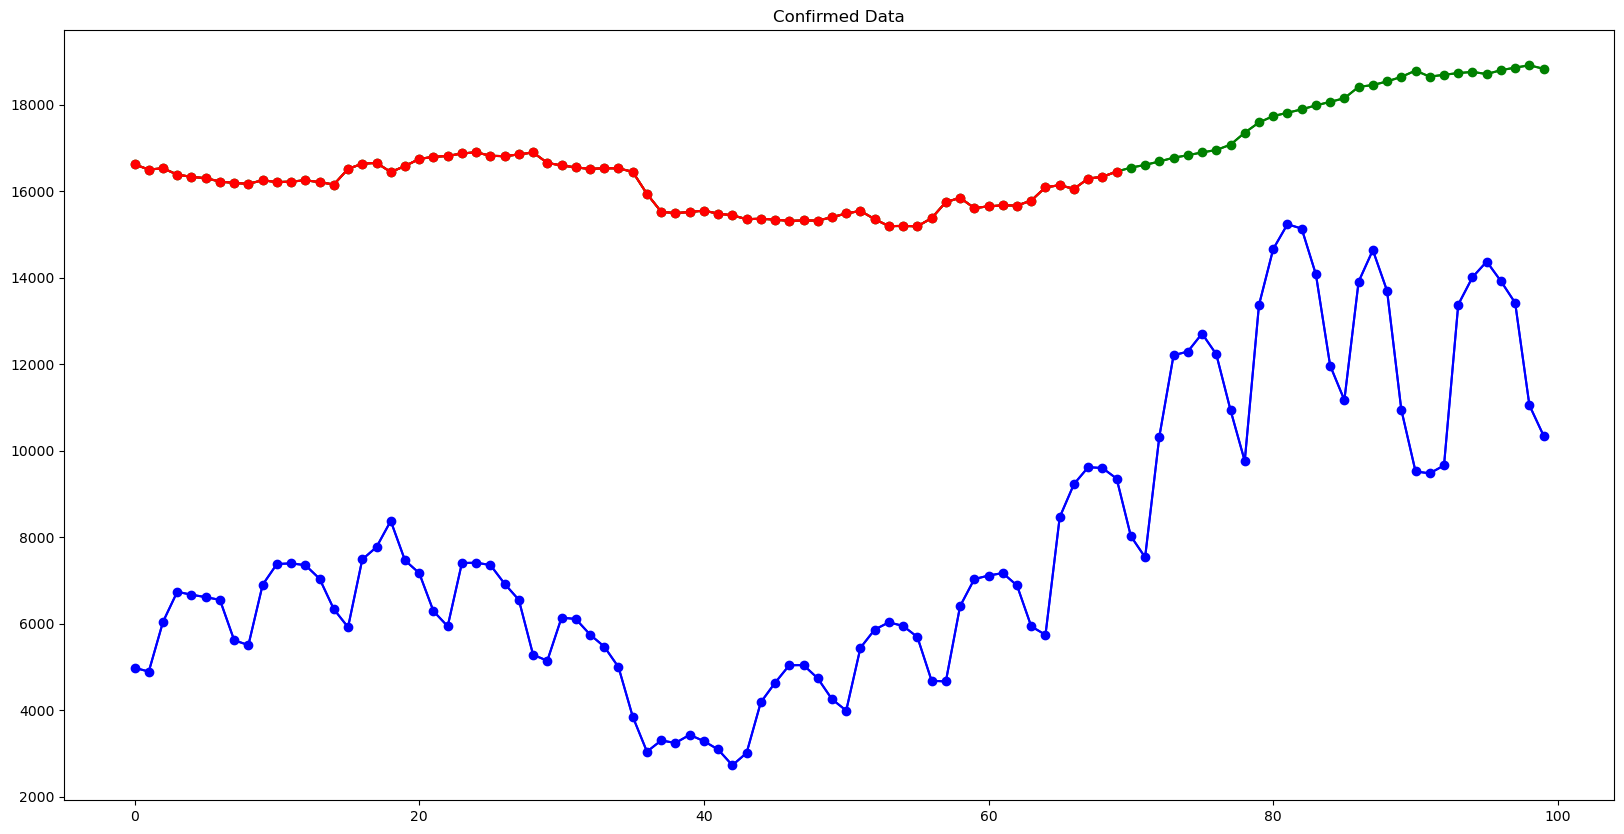

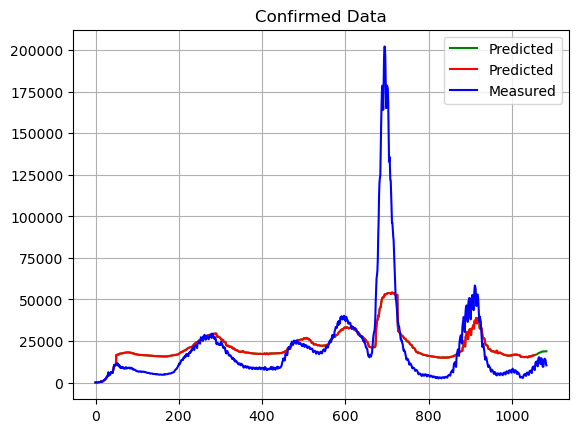

-----------------------------------------------------------------------------------------
| end of epoch  10 | time:  1.58s | mse loss 0.05034 | rmsle loss 0.29033 
-----------------------------------------------------------------------------------------
| epoch  11 |     4/   20 batches | lr 0.002844 | 12.48 ms | loss 0.06409 | ppl     1.07
| epoch  11 |     8/   20 batches | lr 0.002844 |  9.95 ms | loss 1.04240 | ppl     2.84
| epoch  11 |    12/   20 batches | lr 0.002844 |  9.15 ms | loss 0.03369 | ppl     1.03
| epoch  11 |    16/   20 batches | lr 0.002844 |  9.55 ms | loss 0.54839 | ppl     1.73
| epoch  11 |    20/   20 batches | lr 0.002844 |  8.79 ms | loss 0.11033 | ppl     1.12


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  12 |     4/   20 batches | lr 0.002702 | 12.55 ms | loss 0.04070 | ppl     1.04
| epoch  12 |     8/   20 batches | lr 0.002702 | 10.00 ms | loss 0.52238 | ppl     1.69
| epoch  12 |    12/   20 batches | lr 0.002702 | 10.04 ms | loss 0.00923 | ppl     1.01
| epoch  12 |    16/   20 batches | lr 0.002702 |  8.67 ms | loss 0.33401 | ppl     1.40
| epoch  12 |    20/   20 batches | lr 0.002702 |  8.71 ms | loss 0.12443 | ppl     1.13
| epoch  13 |     4/   20 batches | lr 0.002567 | 12.54 ms | loss 0.02068 | ppl     1.02
| epoch  13 |     8/   20 batches | lr 0.002567 |  8.77 ms | loss 1.16775 | ppl     3.21
| epoch  13 |    12/   20 batches | lr 0.002567 | 11.22 ms | loss 0.40901 | ppl     1.51
| epoch  13 |    16/   20 batches | lr 0.002567 |  8.77 ms | loss 0.77912 | ppl     2.18
| epoch  13 |    20/   20 batches | lr 0.002567 |  8.72 ms | loss 0.24782 | ppl     1.28
| epoch  14 |     4/   20 batches | lr 0.002438 | 11.29 ms | loss 0.08790 | ppl     1.09
| epoch  14 |     8/ 

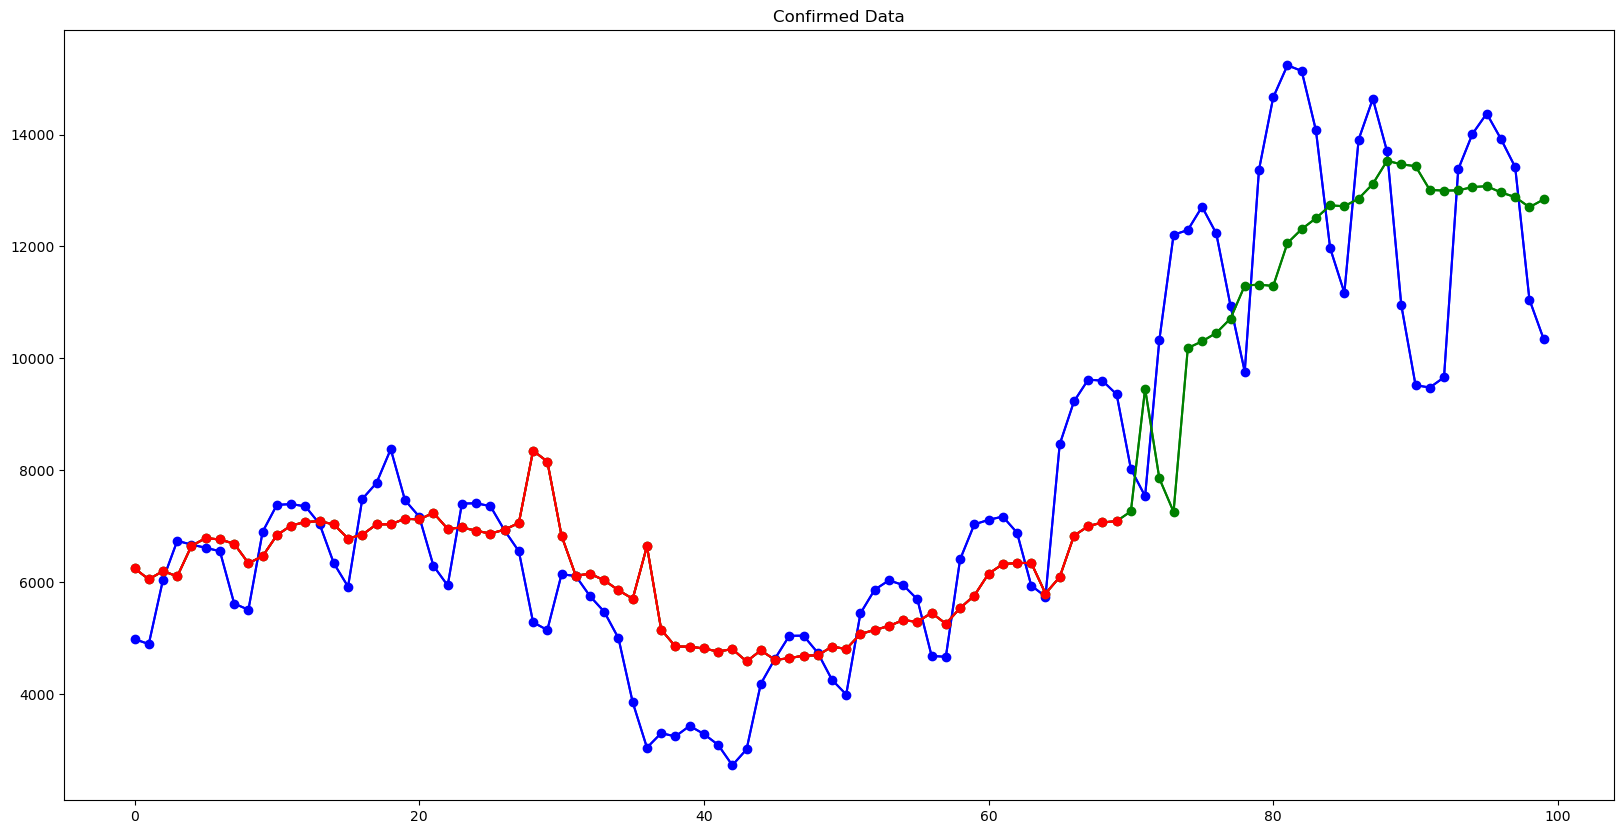

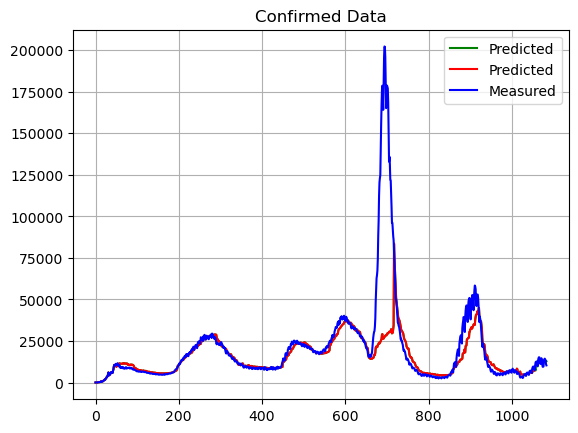

-----------------------------------------------------------------------------------------
| end of epoch  20 | time:  1.64s | mse loss 0.00668 | rmsle loss 0.12168 
-----------------------------------------------------------------------------------------
| epoch  21 |     4/   20 batches | lr 0.001703 | 12.45 ms | loss 0.00452 | ppl     1.00
| epoch  21 |     8/   20 batches | lr 0.001703 | 10.00 ms | loss 1.38374 | ppl     3.99
| epoch  21 |    12/   20 batches | lr 0.001703 | 10.39 ms | loss 0.06801 | ppl     1.07
| epoch  21 |    16/   20 batches | lr 0.001703 |  9.53 ms | loss 1.12529 | ppl     3.08
| epoch  21 |    20/   20 batches | lr 0.001703 |  7.60 ms | loss 0.10715 | ppl     1.11


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  22 |     4/   20 batches | lr 0.001618 | 12.44 ms | loss 0.01689 | ppl     1.02
| epoch  22 |     8/   20 batches | lr 0.001618 | 10.01 ms | loss 1.14630 | ppl     3.15
| epoch  22 |    12/   20 batches | lr 0.001618 | 10.43 ms | loss 0.01750 | ppl     1.02
| epoch  22 |    16/   20 batches | lr 0.001618 |  9.65 ms | loss 0.89349 | ppl     2.44
| epoch  22 |    20/   20 batches | lr 0.001618 |  7.40 ms | loss 0.12247 | ppl     1.13
| epoch  23 |     4/   20 batches | lr 0.001537 | 12.56 ms | loss 0.01802 | ppl     1.02
| epoch  23 |     8/   20 batches | lr 0.001537 |  9.97 ms | loss 1.12299 | ppl     3.07
| epoch  23 |    12/   20 batches | lr 0.001537 | 10.06 ms | loss 0.01637 | ppl     1.02
| epoch  23 |    16/   20 batches | lr 0.001537 |  7.50 ms | loss 0.87482 | ppl     2.40
| epoch  23 |    20/   20 batches | lr 0.001537 | 10.26 ms | loss 0.05848 | ppl     1.06
| epoch  24 |     4/   20 batches | lr 0.001460 | 12.23 ms | loss 0.01042 | ppl     1.01
| epoch  24 |     8/ 

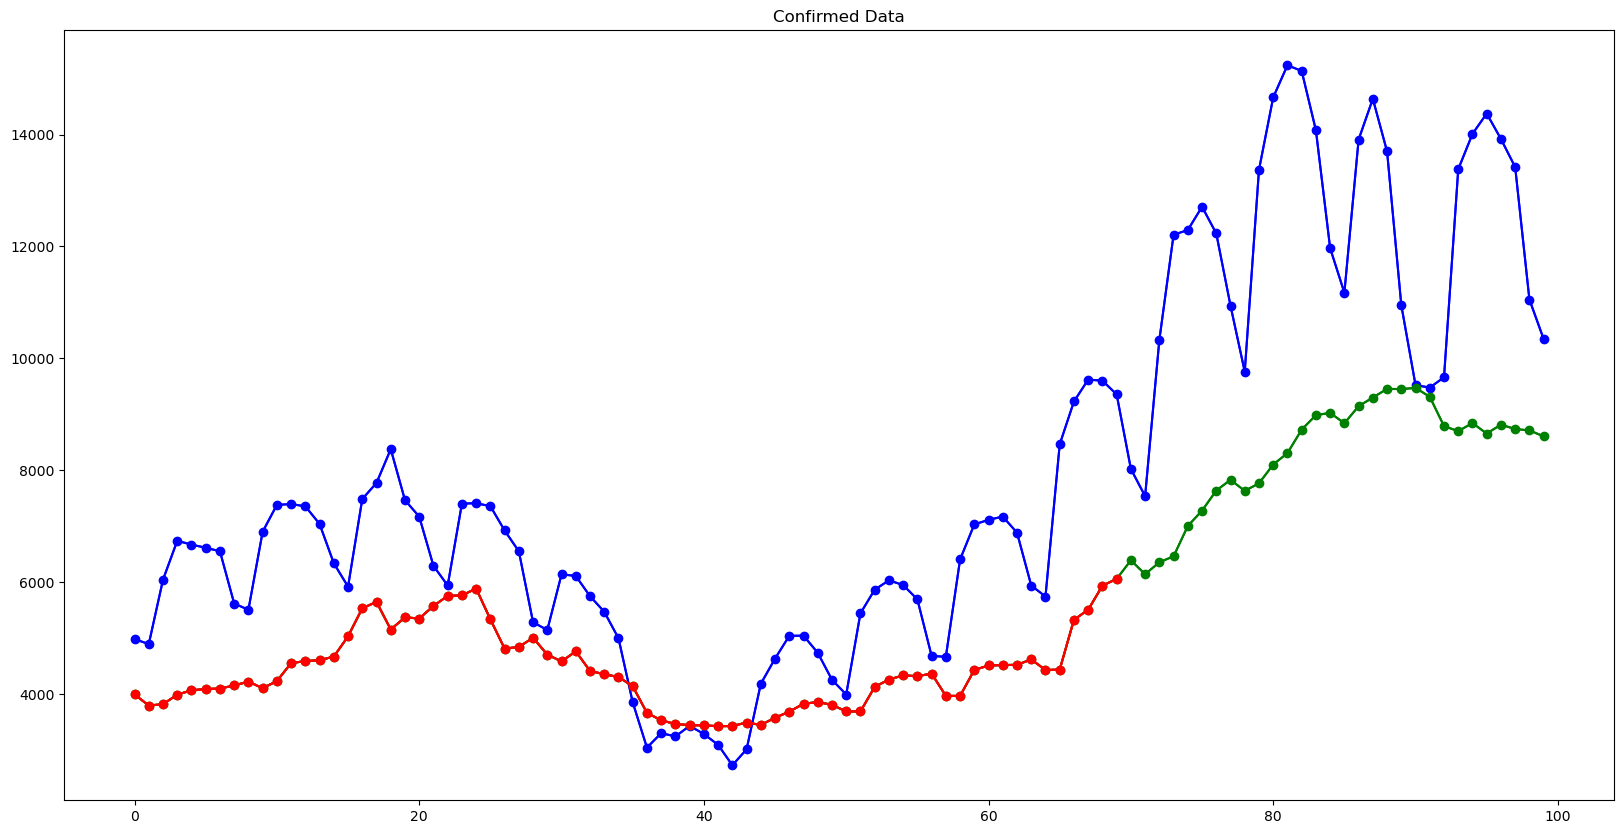

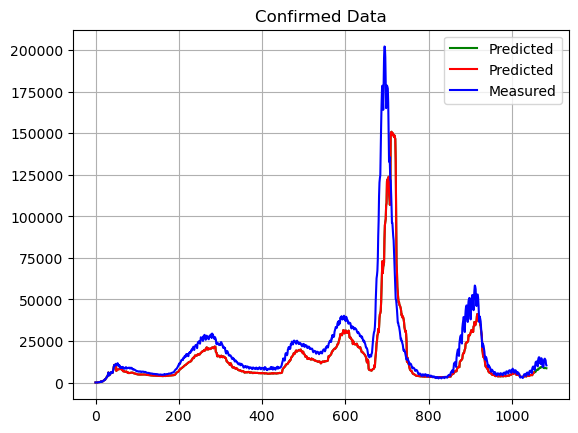

-----------------------------------------------------------------------------------------
| end of epoch  30 | time:  1.67s | mse loss 0.02470 | rmsle loss 0.24284 
-----------------------------------------------------------------------------------------
| epoch  31 |     4/   20 batches | lr 0.001020 | 12.45 ms | loss 0.01716 | ppl     1.02
| epoch  31 |     8/   20 batches | lr 0.001020 | 10.09 ms | loss 1.14424 | ppl     3.14
| epoch  31 |    12/   20 batches | lr 0.001020 |  9.97 ms | loss 0.09000 | ppl     1.09
| epoch  31 |    16/   20 batches | lr 0.001020 |  7.51 ms | loss 0.21163 | ppl     1.24
| epoch  31 |    20/   20 batches | lr 0.001020 |  9.98 ms | loss 0.03612 | ppl     1.04


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  32 |     4/   20 batches | lr 0.000969 | 10.02 ms | loss 0.02802 | ppl     1.03
| epoch  32 |     8/   20 batches | lr 0.000969 | 12.42 ms | loss 0.24975 | ppl     1.28
| epoch  32 |    12/   20 batches | lr 0.000969 |  8.76 ms | loss 0.04150 | ppl     1.04
| epoch  32 |    16/   20 batches | lr 0.000969 | 10.04 ms | loss 0.52450 | ppl     1.69
| epoch  32 |    20/   20 batches | lr 0.000969 |  8.79 ms | loss 0.03237 | ppl     1.03
| epoch  33 |     4/   20 batches | lr 0.000920 | 12.48 ms | loss 0.01034 | ppl     1.01
| epoch  33 |     8/   20 batches | lr 0.000920 |  7.44 ms | loss 1.12417 | ppl     3.08
| epoch  33 |    12/   20 batches | lr 0.000920 |  9.98 ms | loss 0.02362 | ppl     1.02
| epoch  33 |    16/   20 batches | lr 0.000920 | 10.03 ms | loss 1.23651 | ppl     3.44
| epoch  33 |    20/   20 batches | lr 0.000920 |  7.58 ms | loss 0.03123 | ppl     1.03
| epoch  34 |     4/   20 batches | lr 0.000874 | 13.75 ms | loss 0.01020 | ppl     1.01
| epoch  34 |     8/ 

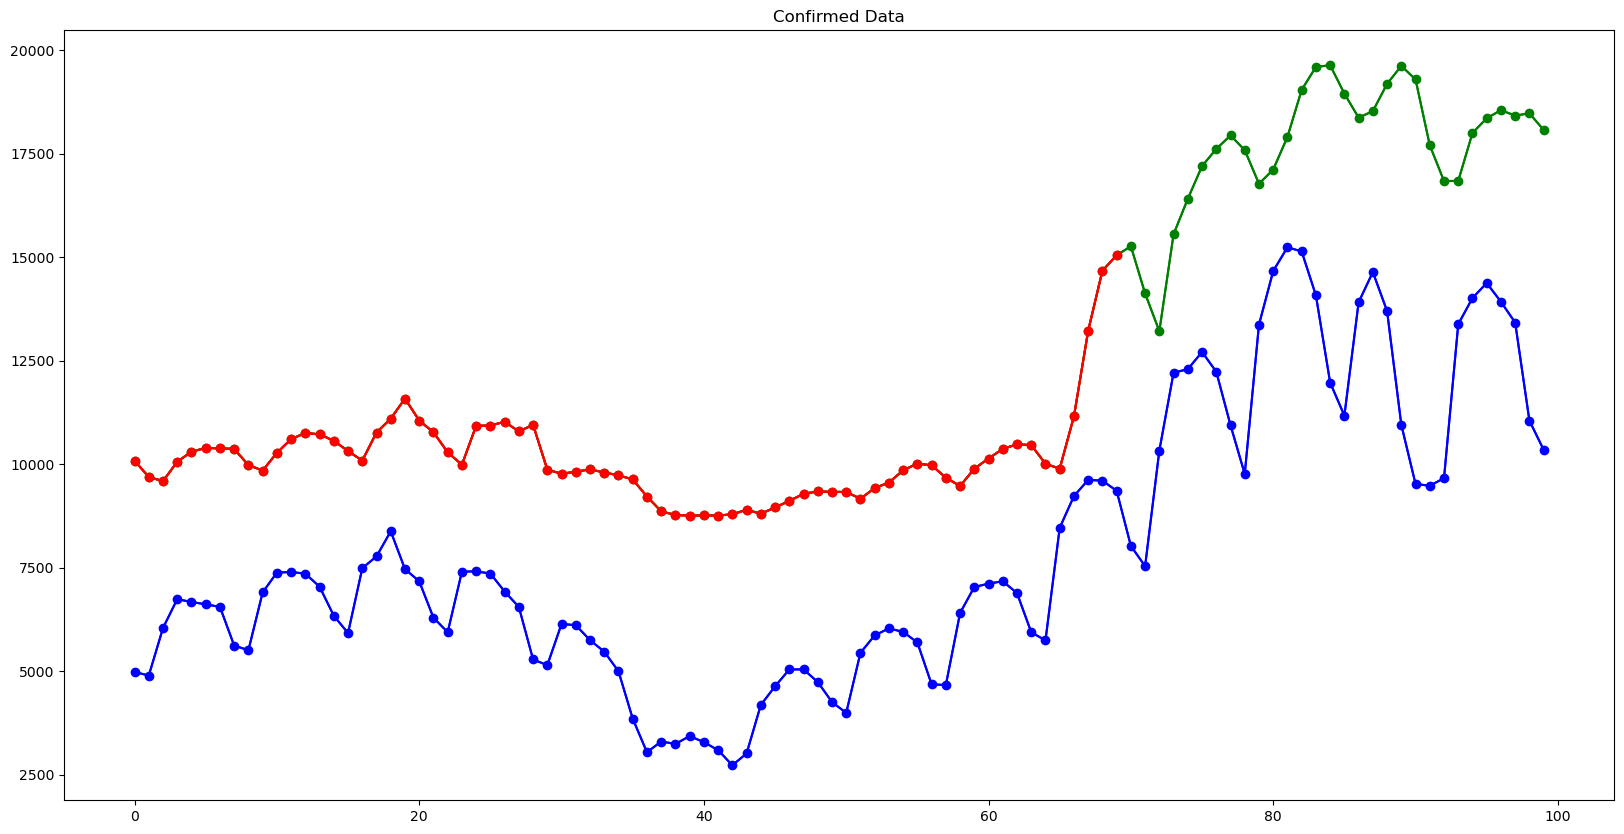

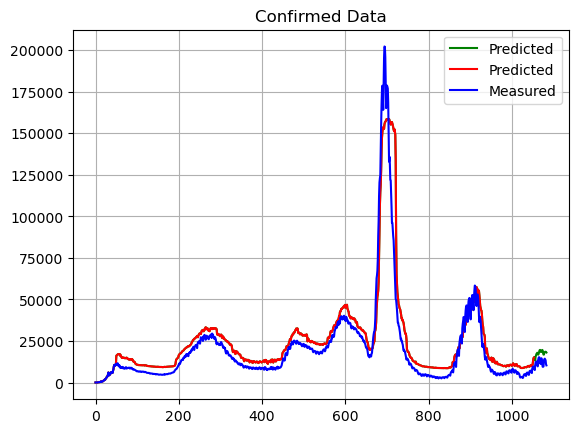

-----------------------------------------------------------------------------------------
| end of epoch  40 | time:  1.54s | mse loss 0.04591 | rmsle loss 0.27610 
-----------------------------------------------------------------------------------------
| epoch  41 |     4/   20 batches | lr 0.000610 | 10.64 ms | loss 0.03398 | ppl     1.03
| epoch  41 |     8/   20 batches | lr 0.000610 |  9.98 ms | loss 0.16326 | ppl     1.18
| epoch  41 |    12/   20 batches | lr 0.000610 | 10.08 ms | loss 0.01618 | ppl     1.02
| epoch  41 |    16/   20 batches | lr 0.000610 | 10.00 ms | loss 0.30478 | ppl     1.36
| epoch  41 |    20/   20 batches | lr 0.000610 |  7.50 ms | loss 0.04934 | ppl     1.05


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  42 |     4/   20 batches | lr 0.000580 | 12.51 ms | loss 0.02062 | ppl     1.02
| epoch  42 |     8/   20 batches | lr 0.000580 | 10.00 ms | loss 0.15190 | ppl     1.16
| epoch  42 |    12/   20 batches | lr 0.000580 |  9.98 ms | loss 0.01266 | ppl     1.01
| epoch  42 |    16/   20 batches | lr 0.000580 | 10.04 ms | loss 0.20436 | ppl     1.23
| epoch  42 |    20/   20 batches | lr 0.000580 |  7.45 ms | loss 0.02479 | ppl     1.03
| epoch  43 |     4/   20 batches | lr 0.000551 | 12.49 ms | loss 0.01385 | ppl     1.01
| epoch  43 |     8/   20 batches | lr 0.000551 |  9.97 ms | loss 0.17913 | ppl     1.20
| epoch  43 |    12/   20 batches | lr 0.000551 | 11.21 ms | loss 0.01073 | ppl     1.01
| epoch  43 |    16/   20 batches | lr 0.000551 |  8.80 ms | loss 0.23340 | ppl     1.26
| epoch  43 |    20/   20 batches | lr 0.000551 |  7.49 ms | loss 0.03533 | ppl     1.04
| epoch  44 |     4/   20 batches | lr 0.000523 | 12.56 ms | loss 0.01613 | ppl     1.02
| epoch  44 |     8/ 

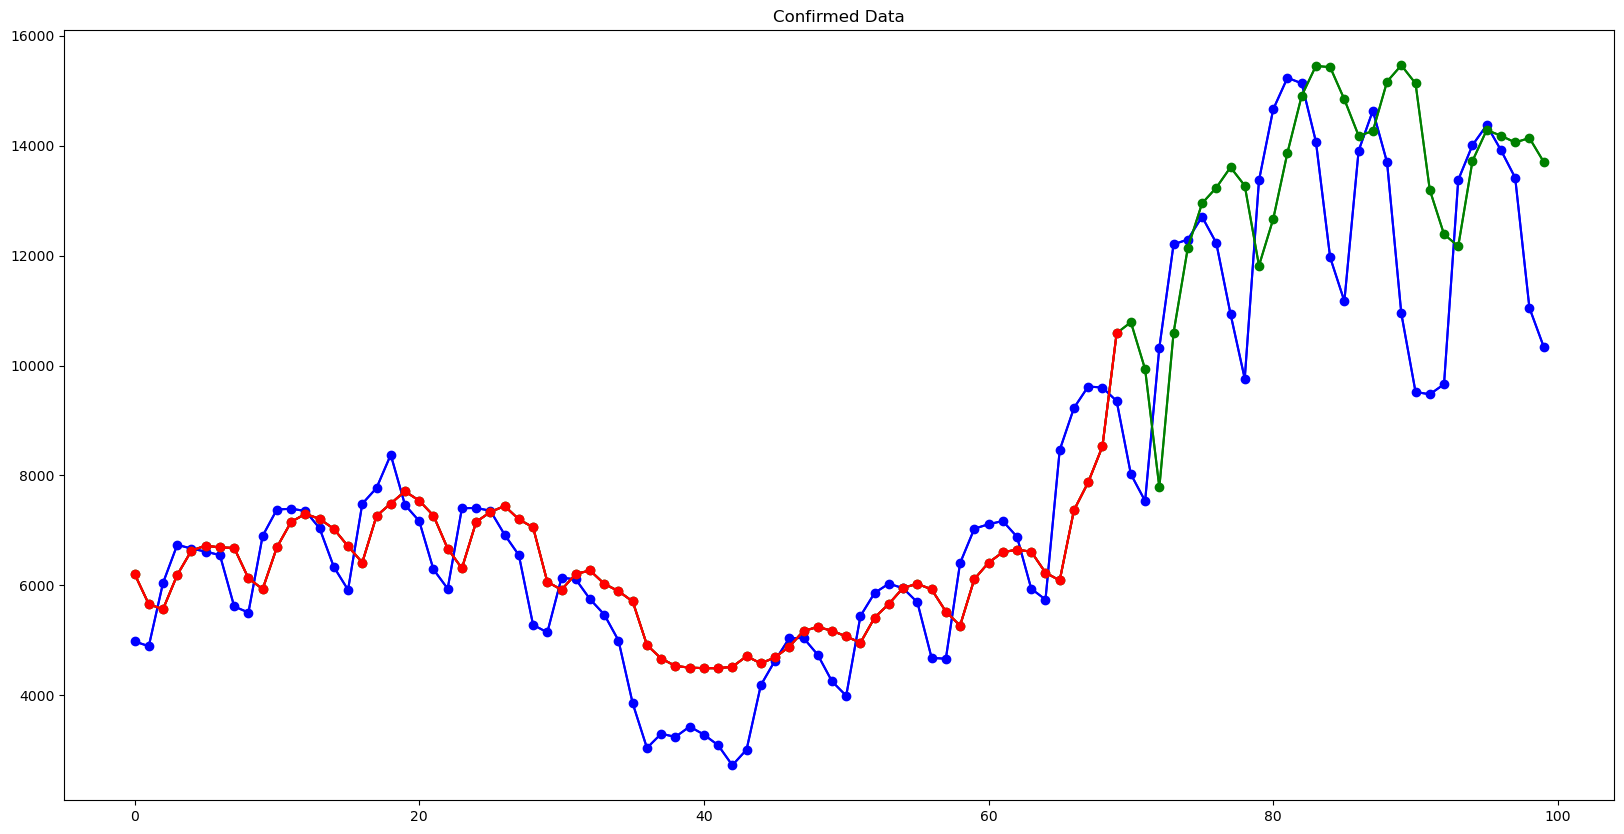

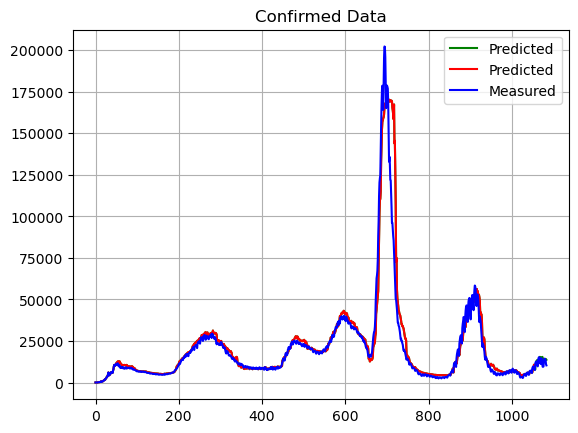

-----------------------------------------------------------------------------------------
| end of epoch  50 | time:  1.61s | mse loss 0.00782 | rmsle loss 0.12754 
-----------------------------------------------------------------------------------------
| epoch  51 |     4/   20 batches | lr 0.000365 | 11.22 ms | loss 0.00486 | ppl     1.00
| epoch  51 |     8/   20 batches | lr 0.000365 |  9.94 ms | loss 0.12744 | ppl     1.14
| epoch  51 |    12/   20 batches | lr 0.000365 | 10.05 ms | loss 0.00385 | ppl     1.00
| epoch  51 |    16/   20 batches | lr 0.000365 |  9.98 ms | loss 0.14936 | ppl     1.16
| epoch  51 |    20/   20 batches | lr 0.000365 |  7.54 ms | loss 0.01705 | ppl     1.02


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  52 |     4/   20 batches | lr 0.000347 | 12.40 ms | loss 0.00552 | ppl     1.01
| epoch  52 |     8/   20 batches | lr 0.000347 | 10.01 ms | loss 0.11818 | ppl     1.13
| epoch  52 |    12/   20 batches | lr 0.000347 | 10.09 ms | loss 0.00428 | ppl     1.00
| epoch  52 |    16/   20 batches | lr 0.000347 | 10.01 ms | loss 0.12752 | ppl     1.14
| epoch  52 |    20/   20 batches | lr 0.000347 |  7.53 ms | loss 0.01333 | ppl     1.01
| epoch  53 |     4/   20 batches | lr 0.000330 | 12.46 ms | loss 0.00453 | ppl     1.00
| epoch  53 |     8/   20 batches | lr 0.000330 |  9.92 ms | loss 0.09419 | ppl     1.10
| epoch  53 |    12/   20 batches | lr 0.000330 | 10.08 ms | loss 0.00339 | ppl     1.00
| epoch  53 |    16/   20 batches | lr 0.000330 |  7.46 ms | loss 0.09387 | ppl     1.10
| epoch  53 |    20/   20 batches | lr 0.000330 | 10.07 ms | loss 0.01249 | ppl     1.01
| epoch  54 |     4/   20 batches | lr 0.000313 | 12.46 ms | loss 0.00373 | ppl     1.00
| epoch  54 |     8/ 

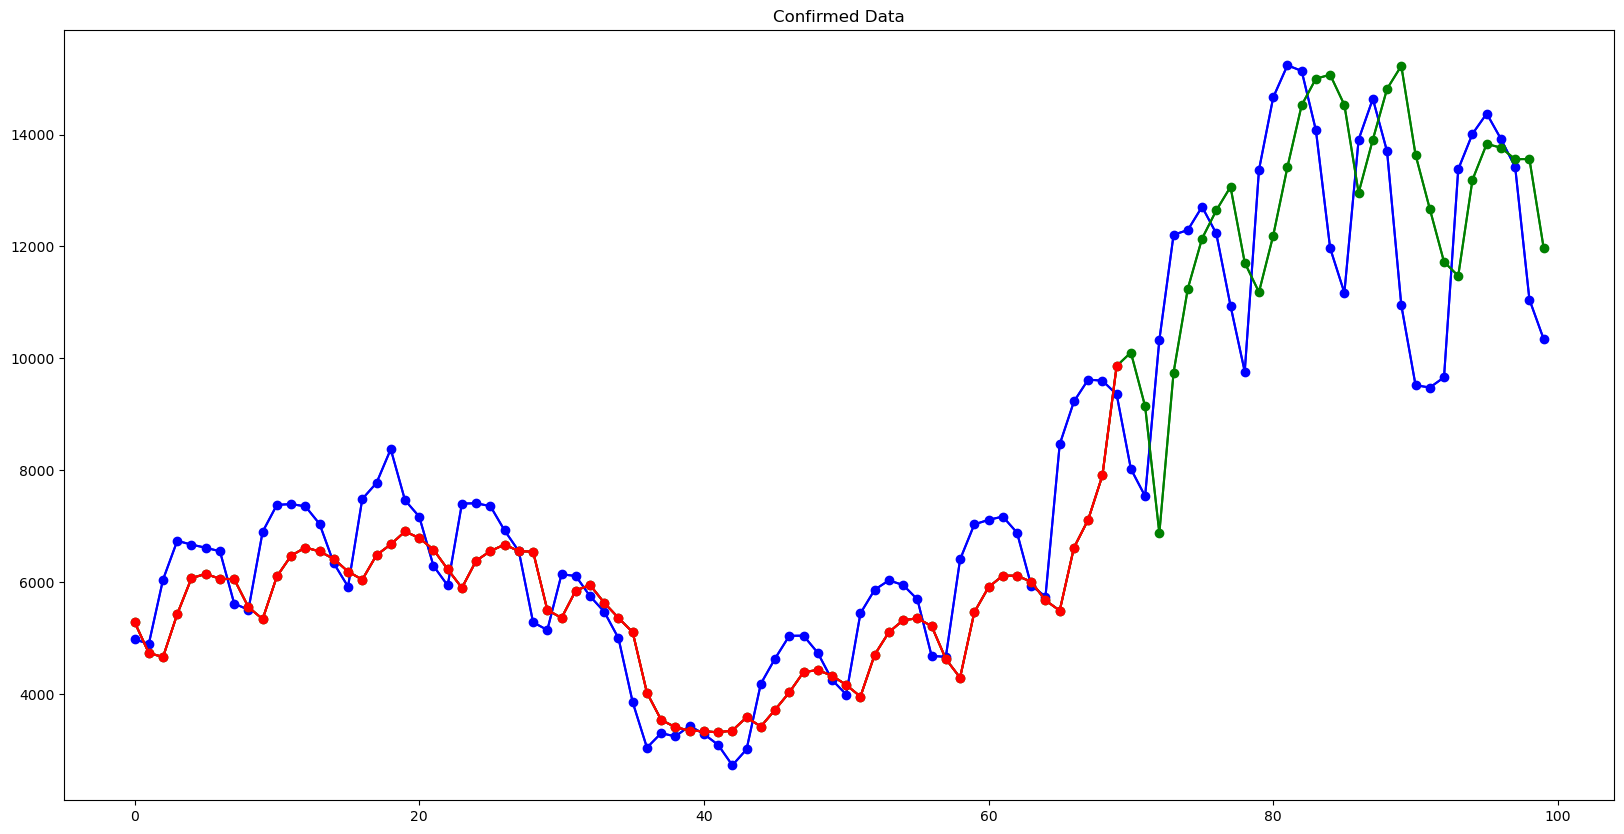

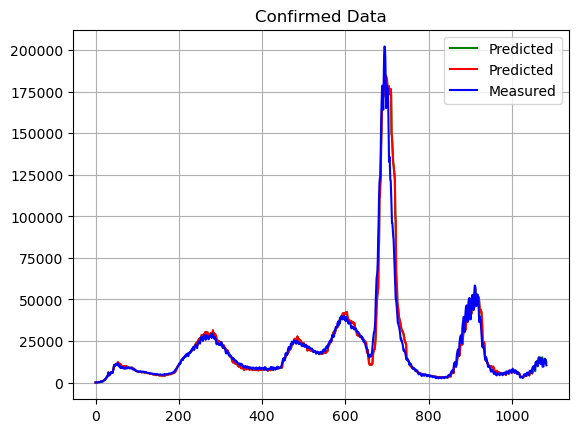

-----------------------------------------------------------------------------------------
| end of epoch  60 | time:  1.53s | mse loss 0.00605 | rmsle loss 0.11419 
-----------------------------------------------------------------------------------------
| epoch  61 |     4/   20 batches | lr 0.000219 | 12.41 ms | loss 0.00359 | ppl     1.00
| epoch  61 |     8/   20 batches | lr 0.000219 | 10.03 ms | loss 0.08545 | ppl     1.09
| epoch  61 |    12/   20 batches | lr 0.000219 |  9.97 ms | loss 0.00357 | ppl     1.00
| epoch  61 |    16/   20 batches | lr 0.000219 | 10.04 ms | loss 0.06647 | ppl     1.07
| epoch  61 |    20/   20 batches | lr 0.000219 |  8.80 ms | loss 0.01277 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  62 |     4/   20 batches | lr 0.000208 | 11.17 ms | loss 0.00378 | ppl     1.00
| epoch  62 |     8/   20 batches | lr 0.000208 |  8.78 ms | loss 0.07260 | ppl     1.08
| epoch  62 |    12/   20 batches | lr 0.000208 |  9.98 ms | loss 0.00352 | ppl     1.00
| epoch  62 |    16/   20 batches | lr 0.000208 | 10.04 ms | loss 0.06061 | ppl     1.06
| epoch  62 |    20/   20 batches | lr 0.000208 |  8.76 ms | loss 0.01374 | ppl     1.01
| epoch  63 |     4/   20 batches | lr 0.000197 | 13.69 ms | loss 0.00386 | ppl     1.00
| epoch  63 |     8/   20 batches | lr 0.000197 | 10.03 ms | loss 0.07103 | ppl     1.07
| epoch  63 |    12/   20 batches | lr 0.000197 | 10.03 ms | loss 0.00339 | ppl     1.00
| epoch  63 |    16/   20 batches | lr 0.000197 | 10.04 ms | loss 0.06371 | ppl     1.07
| epoch  63 |    20/   20 batches | lr 0.000197 |  7.47 ms | loss 0.01291 | ppl     1.01
| epoch  64 |     4/   20 batches | lr 0.000188 | 13.11 ms | loss 0.00374 | ppl     1.00
| epoch  64 |     8/ 

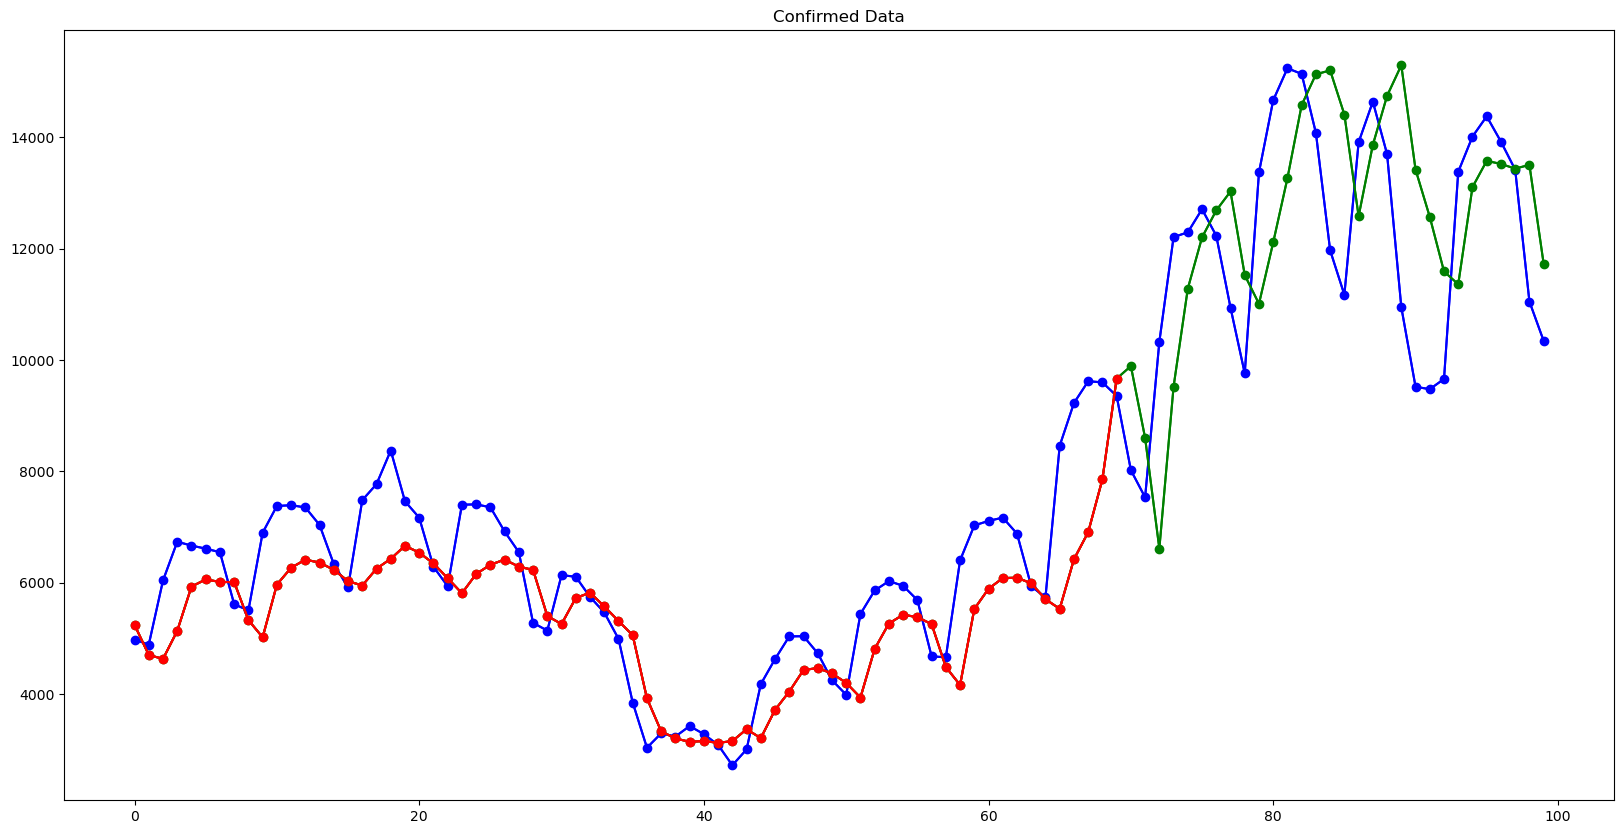

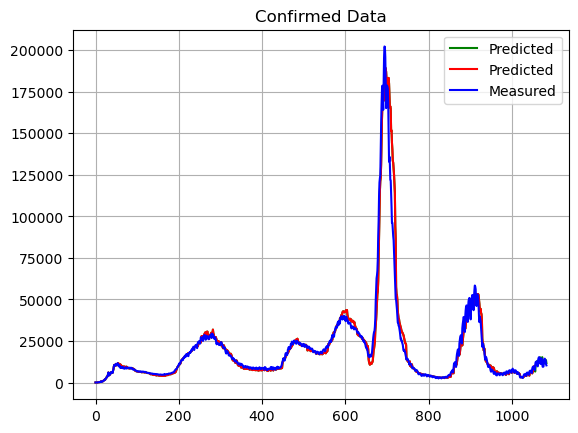

-----------------------------------------------------------------------------------------
| end of epoch  70 | time:  1.74s | mse loss 0.00606 | rmsle loss 0.11429 
-----------------------------------------------------------------------------------------
| epoch  71 |     4/   20 batches | lr 0.000131 | 13.67 ms | loss 0.00360 | ppl     1.00
| epoch  71 |     8/   20 batches | lr 0.000131 | 11.29 ms | loss 0.06209 | ppl     1.06
| epoch  71 |    12/   20 batches | lr 0.000131 |  9.93 ms | loss 0.00327 | ppl     1.00
| epoch  71 |    16/   20 batches | lr 0.000131 | 10.06 ms | loss 0.06773 | ppl     1.07


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  71 |    20/   20 batches | lr 0.000131 |  7.52 ms | loss 0.01146 | ppl     1.01
| epoch  72 |     4/   20 batches | lr 0.000124 | 12.45 ms | loss 0.00363 | ppl     1.00
| epoch  72 |     8/   20 batches | lr 0.000124 | 10.02 ms | loss 0.06396 | ppl     1.07
| epoch  72 |    12/   20 batches | lr 0.000124 | 10.04 ms | loss 0.00351 | ppl     1.00
| epoch  72 |    16/   20 batches | lr 0.000124 |  9.92 ms | loss 0.05072 | ppl     1.05
| epoch  72 |    20/   20 batches | lr 0.000124 |  8.83 ms | loss 0.01391 | ppl     1.01
| epoch  73 |     4/   20 batches | lr 0.000118 | 12.46 ms | loss 0.00347 | ppl     1.00
| epoch  73 |     8/   20 batches | lr 0.000118 | 10.05 ms | loss 0.07206 | ppl     1.07
| epoch  73 |    12/   20 batches | lr 0.000118 |  9.92 ms | loss 0.00346 | ppl     1.00
| epoch  73 |    16/   20 batches | lr 0.000118 | 10.00 ms | loss 0.05545 | ppl     1.06
| epoch  73 |    20/   20 batches | lr 0.000118 |  7.53 ms | loss 0.01142 | ppl     1.01
| epoch  74 |     4/ 

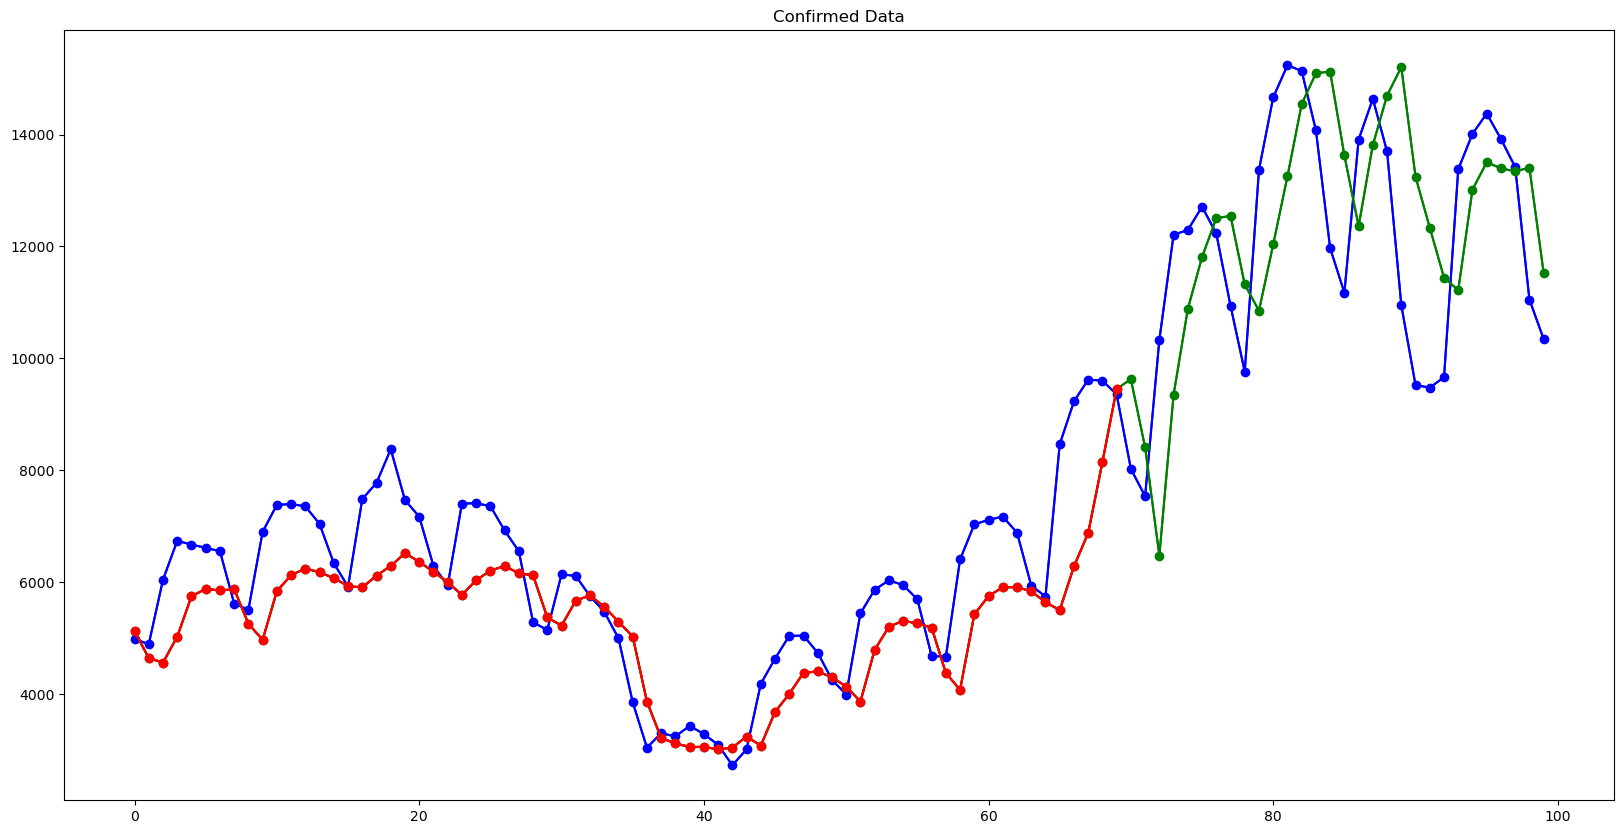

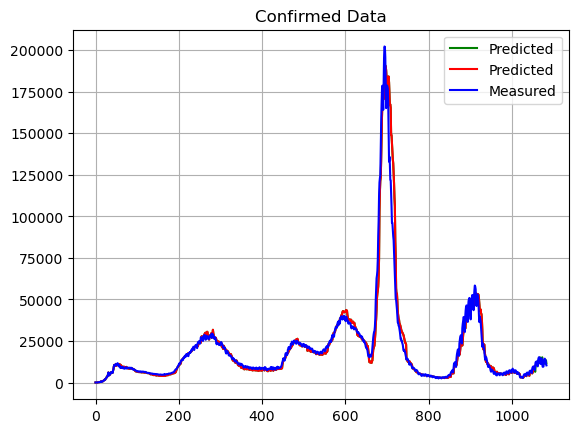

-----------------------------------------------------------------------------------------
| end of epoch  80 | time:  1.67s | mse loss 0.00573 | rmsle loss 0.11177 
-----------------------------------------------------------------------------------------
| epoch  81 |     4/   20 batches | lr 0.000078 | 12.53 ms | loss 0.00354 | ppl     1.00
| epoch  81 |     8/   20 batches | lr 0.000078 | 10.05 ms | loss 0.05550 | ppl     1.06
| epoch  81 |    12/   20 batches | lr 0.000078 | 12.52 ms | loss 0.00344 | ppl     1.00
| epoch  81 |    16/   20 batches | lr 0.000078 |  9.96 ms | loss 0.04683 | ppl     1.05


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  81 |    20/   20 batches | lr 0.000078 |  7.42 ms | loss 0.01209 | ppl     1.01
| epoch  82 |     4/   20 batches | lr 0.000075 | 12.83 ms | loss 0.00358 | ppl     1.00
| epoch  82 |     8/   20 batches | lr 0.000075 | 12.26 ms | loss 0.05371 | ppl     1.06
| epoch  82 |    12/   20 batches | lr 0.000075 |  9.91 ms | loss 0.00345 | ppl     1.00
| epoch  82 |    16/   20 batches | lr 0.000075 | 11.14 ms | loss 0.04840 | ppl     1.05
| epoch  82 |    20/   20 batches | lr 0.000075 |  8.96 ms | loss 0.01135 | ppl     1.01
| epoch  83 |     4/   20 batches | lr 0.000071 | 12.39 ms | loss 0.00362 | ppl     1.00
| epoch  83 |     8/   20 batches | lr 0.000071 | 10.03 ms | loss 0.05621 | ppl     1.06
| epoch  83 |    12/   20 batches | lr 0.000071 | 10.06 ms | loss 0.00338 | ppl     1.00
| epoch  83 |    16/   20 batches | lr 0.000071 | 10.00 ms | loss 0.04666 | ppl     1.05
| epoch  83 |    20/   20 batches | lr 0.000071 |  9.96 ms | loss 0.01243 | ppl     1.01
| epoch  84 |     4/ 

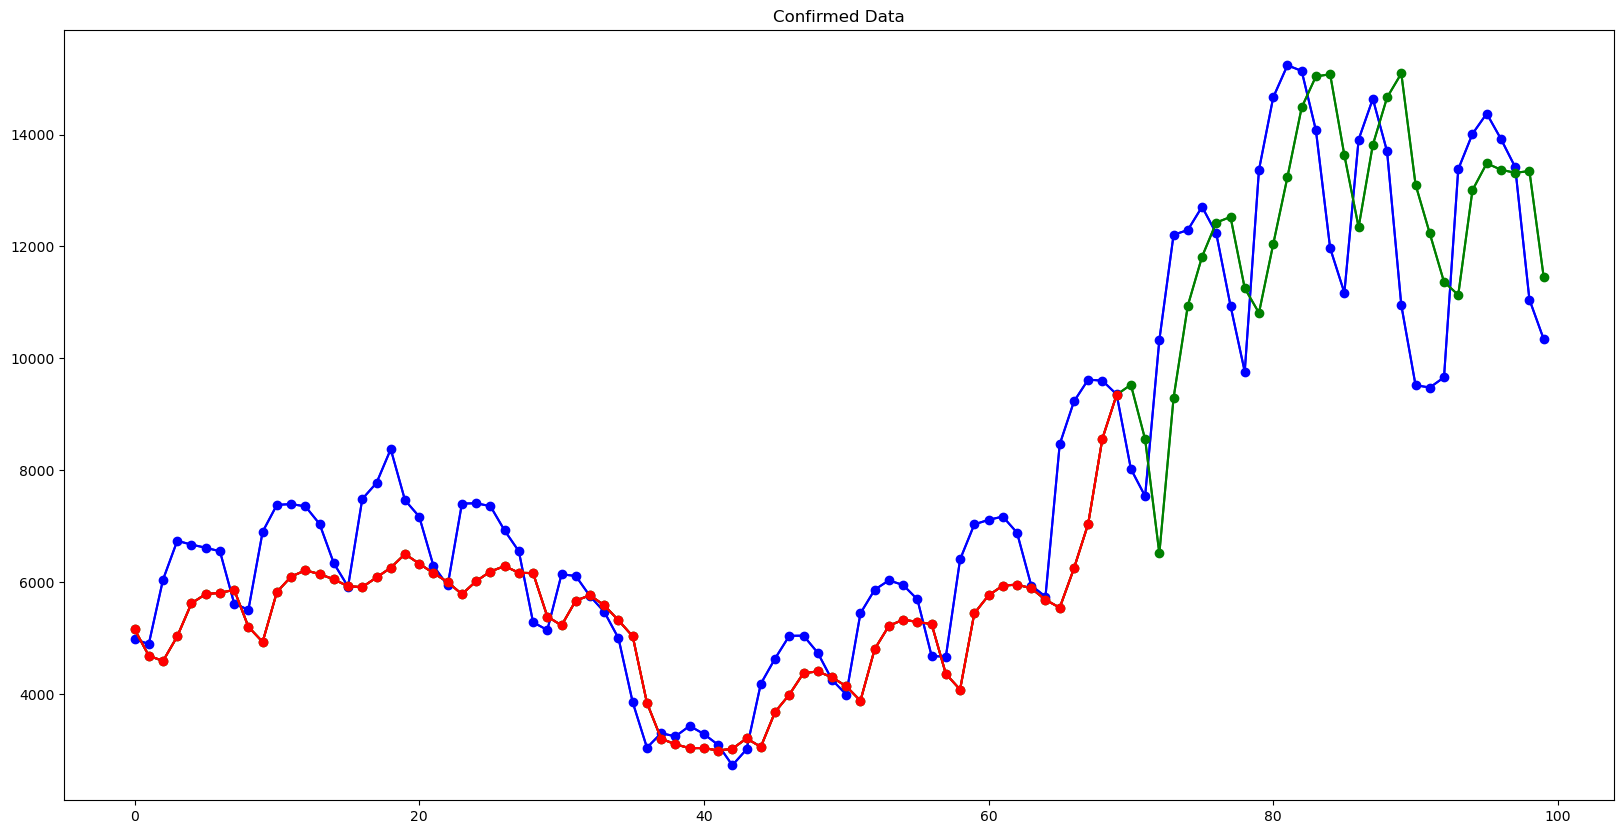

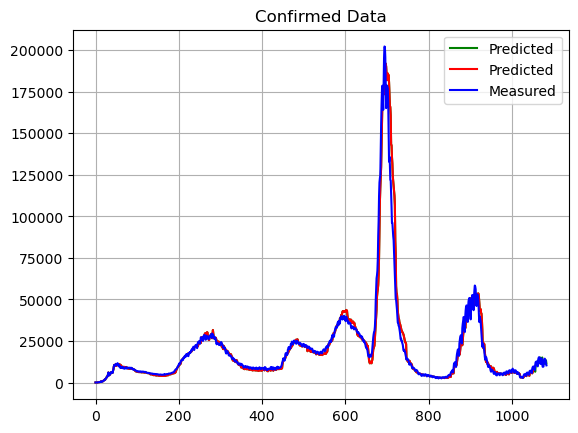

-----------------------------------------------------------------------------------------
| end of epoch  90 | time:  1.66s | mse loss 0.00558 | rmsle loss 0.11040 
-----------------------------------------------------------------------------------------
| epoch  91 |     4/   20 batches | lr 0.000047 | 12.71 ms | loss 0.00352 | ppl     1.00
| epoch  91 |     8/   20 batches | lr 0.000047 |  9.81 ms | loss 0.04935 | ppl     1.05
| epoch  91 |    12/   20 batches | lr 0.000047 |  9.92 ms | loss 0.00338 | ppl     1.00
| epoch  91 |    16/   20 batches | lr 0.000047 |  7.57 ms | loss 0.04531 | ppl     1.05
| epoch  91 |    20/   20 batches | lr 0.000047 | 10.10 ms | loss 0.01321 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch  92 |     4/   20 batches | lr 0.000045 | 12.33 ms | loss 0.00359 | ppl     1.00
| epoch  92 |     8/   20 batches | lr 0.000045 | 10.11 ms | loss 0.05087 | ppl     1.05
| epoch  92 |    12/   20 batches | lr 0.000045 |  9.94 ms | loss 0.00344 | ppl     1.00
| epoch  92 |    16/   20 batches | lr 0.000045 |  9.99 ms | loss 0.04124 | ppl     1.04
| epoch  92 |    20/   20 batches | lr 0.000045 |  7.55 ms | loss 0.01239 | ppl     1.01
| epoch  93 |     4/   20 batches | lr 0.000042 | 12.49 ms | loss 0.00359 | ppl     1.00
| epoch  93 |     8/   20 batches | lr 0.000042 |  9.94 ms | loss 0.05114 | ppl     1.05
| epoch  93 |    12/   20 batches | lr 0.000042 | 10.08 ms | loss 0.00335 | ppl     1.00
| epoch  93 |    16/   20 batches | lr 0.000042 | 10.01 ms | loss 0.04120 | ppl     1.04
| epoch  93 |    20/   20 batches | lr 0.000042 |  7.47 ms | loss 0.01166 | ppl     1.01
| epoch  94 |     4/   20 batches | lr 0.000040 | 13.01 ms | loss 0.00351 | ppl     1.00
| epoch  94 |     8/ 

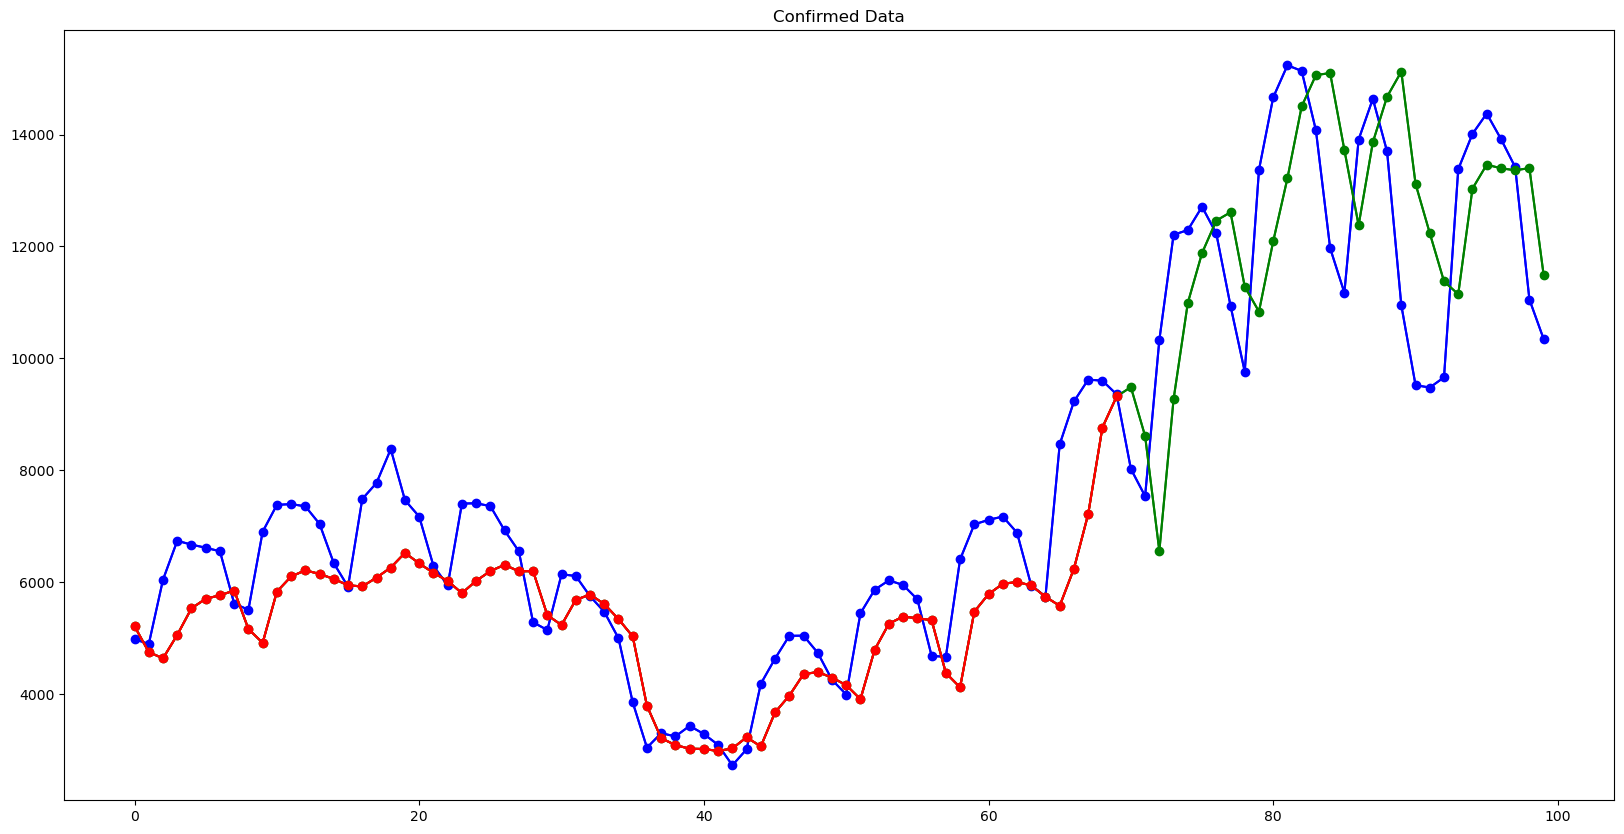

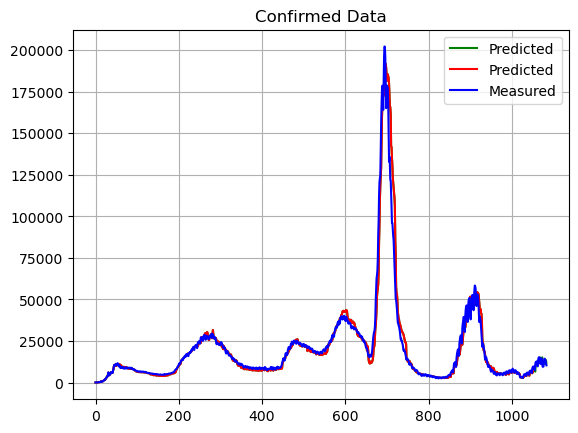

-----------------------------------------------------------------------------------------
| end of epoch 100 | time:  1.73s | mse loss 0.00561 | rmsle loss 0.11058 
-----------------------------------------------------------------------------------------
| epoch 101 |     4/   20 batches | lr 0.000028 | 15.01 ms | loss 0.00355 | ppl     1.00
| epoch 101 |     8/   20 batches | lr 0.000028 | 10.09 ms | loss 0.05088 | ppl     1.05
| epoch 101 |    12/   20 batches | lr 0.000028 |  9.89 ms | loss 0.00341 | ppl     1.00
| epoch 101 |    16/   20 batches | lr 0.000028 | 10.05 ms | loss 0.04035 | ppl     1.04


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 101 |    20/   20 batches | lr 0.000028 |  7.57 ms | loss 0.01258 | ppl     1.01
| epoch 102 |     4/   20 batches | lr 0.000027 | 12.42 ms | loss 0.00362 | ppl     1.00
| epoch 102 |     8/   20 batches | lr 0.000027 |  9.97 ms | loss 0.04964 | ppl     1.05
| epoch 102 |    12/   20 batches | lr 0.000027 |  9.98 ms | loss 0.00340 | ppl     1.00
| epoch 102 |    16/   20 batches | lr 0.000027 | 10.10 ms | loss 0.03902 | ppl     1.04
| epoch 102 |    20/   20 batches | lr 0.000027 |  8.11 ms | loss 0.01293 | ppl     1.01
| epoch 103 |     4/   20 batches | lr 0.000025 | 11.82 ms | loss 0.00352 | ppl     1.00
| epoch 103 |     8/   20 batches | lr 0.000025 |  9.98 ms | loss 0.04805 | ppl     1.05
| epoch 103 |    12/   20 batches | lr 0.000025 | 10.10 ms | loss 0.00343 | ppl     1.00
| epoch 103 |    16/   20 batches | lr 0.000025 | 11.15 ms | loss 0.04014 | ppl     1.04
| epoch 103 |    20/   20 batches | lr 0.000025 |  8.79 ms | loss 0.01249 | ppl     1.01
| epoch 104 |     4/ 

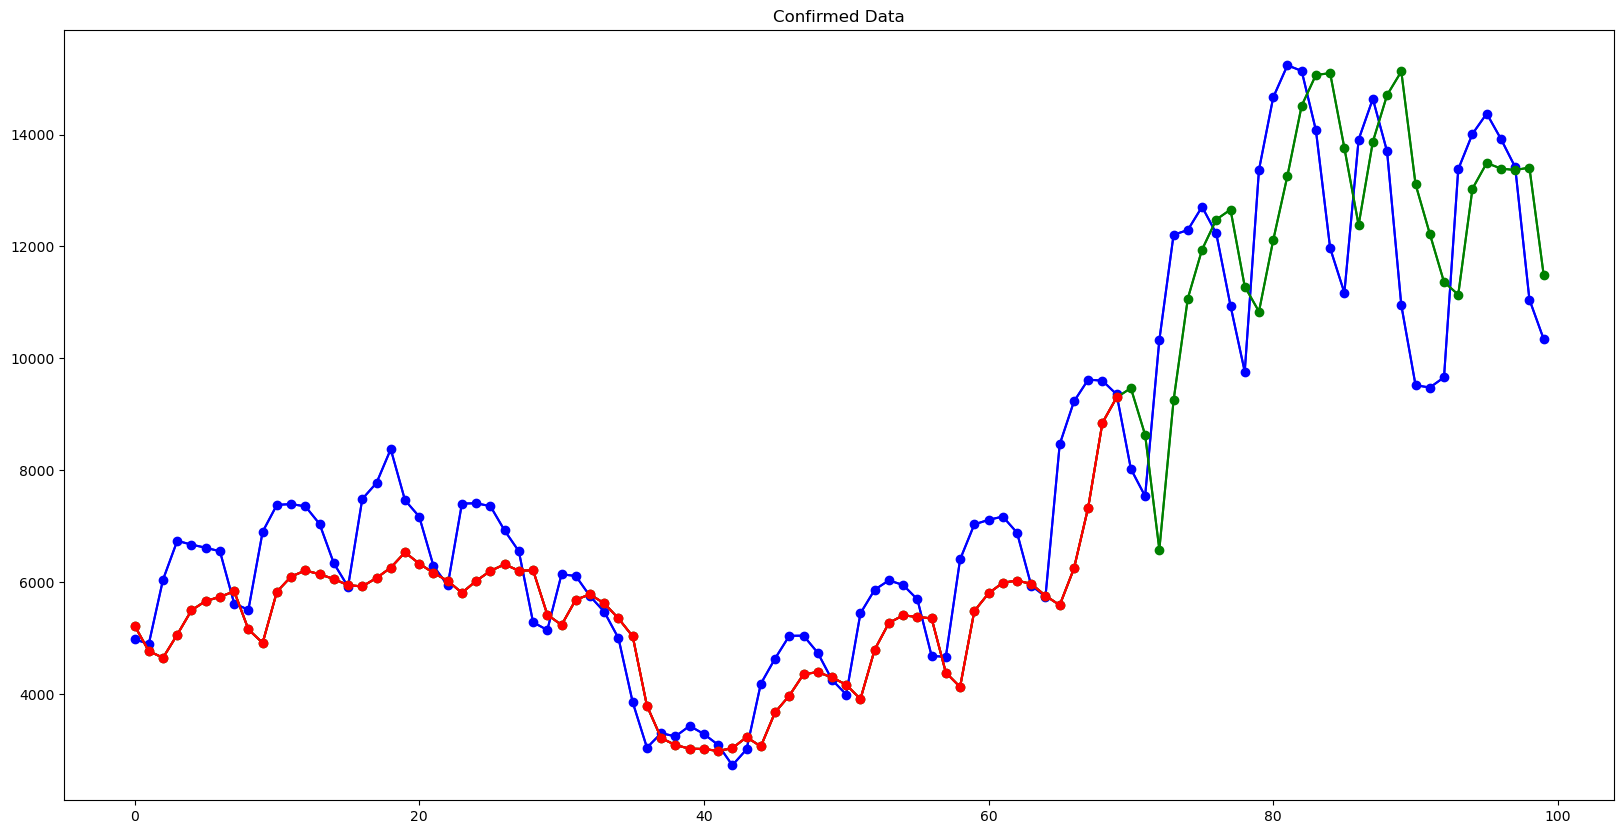

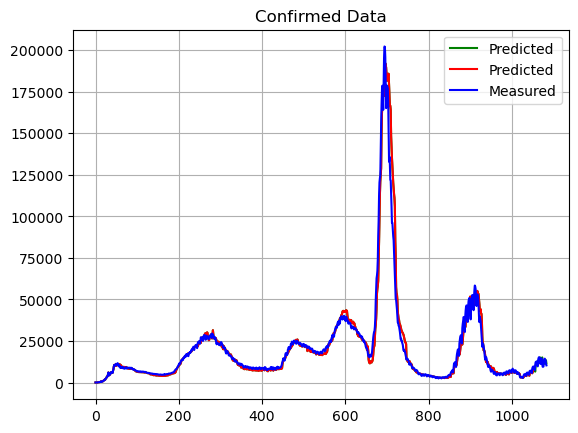

-----------------------------------------------------------------------------------------
| end of epoch 110 | time:  1.54s | mse loss 0.00559 | rmsle loss 0.11038 
-----------------------------------------------------------------------------------------
| epoch 111 |     4/   20 batches | lr 0.000017 | 12.48 ms | loss 0.00358 | ppl     1.00
| epoch 111 |     8/   20 batches | lr 0.000017 | 10.37 ms | loss 0.04757 | ppl     1.05
| epoch 111 |    12/   20 batches | lr 0.000017 |  9.73 ms | loss 0.00335 | ppl     1.00
| epoch 111 |    16/   20 batches | lr 0.000017 |  9.87 ms | loss 0.03991 | ppl     1.04


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 111 |    20/   20 batches | lr 0.000017 |  9.99 ms | loss 0.01210 | ppl     1.01
| epoch 112 |     4/   20 batches | lr 0.000016 | 12.52 ms | loss 0.00348 | ppl     1.00
| epoch 112 |     8/   20 batches | lr 0.000016 | 10.09 ms | loss 0.04710 | ppl     1.05
| epoch 112 |    12/   20 batches | lr 0.000016 |  9.90 ms | loss 0.00342 | ppl     1.00
| epoch 112 |    16/   20 batches | lr 0.000016 | 10.08 ms | loss 0.03763 | ppl     1.04
| epoch 112 |    20/   20 batches | lr 0.000016 |  9.92 ms | loss 0.01230 | ppl     1.01
| epoch 113 |     4/   20 batches | lr 0.000015 | 12.53 ms | loss 0.00350 | ppl     1.00
| epoch 113 |     8/   20 batches | lr 0.000015 | 10.56 ms | loss 0.04799 | ppl     1.05
| epoch 113 |    12/   20 batches | lr 0.000015 |  9.50 ms | loss 0.00335 | ppl     1.00
| epoch 113 |    16/   20 batches | lr 0.000015 |  9.93 ms | loss 0.03960 | ppl     1.04
| epoch 113 |    20/   20 batches | lr 0.000015 |  7.46 ms | loss 0.01248 | ppl     1.01
| epoch 114 |     4/ 

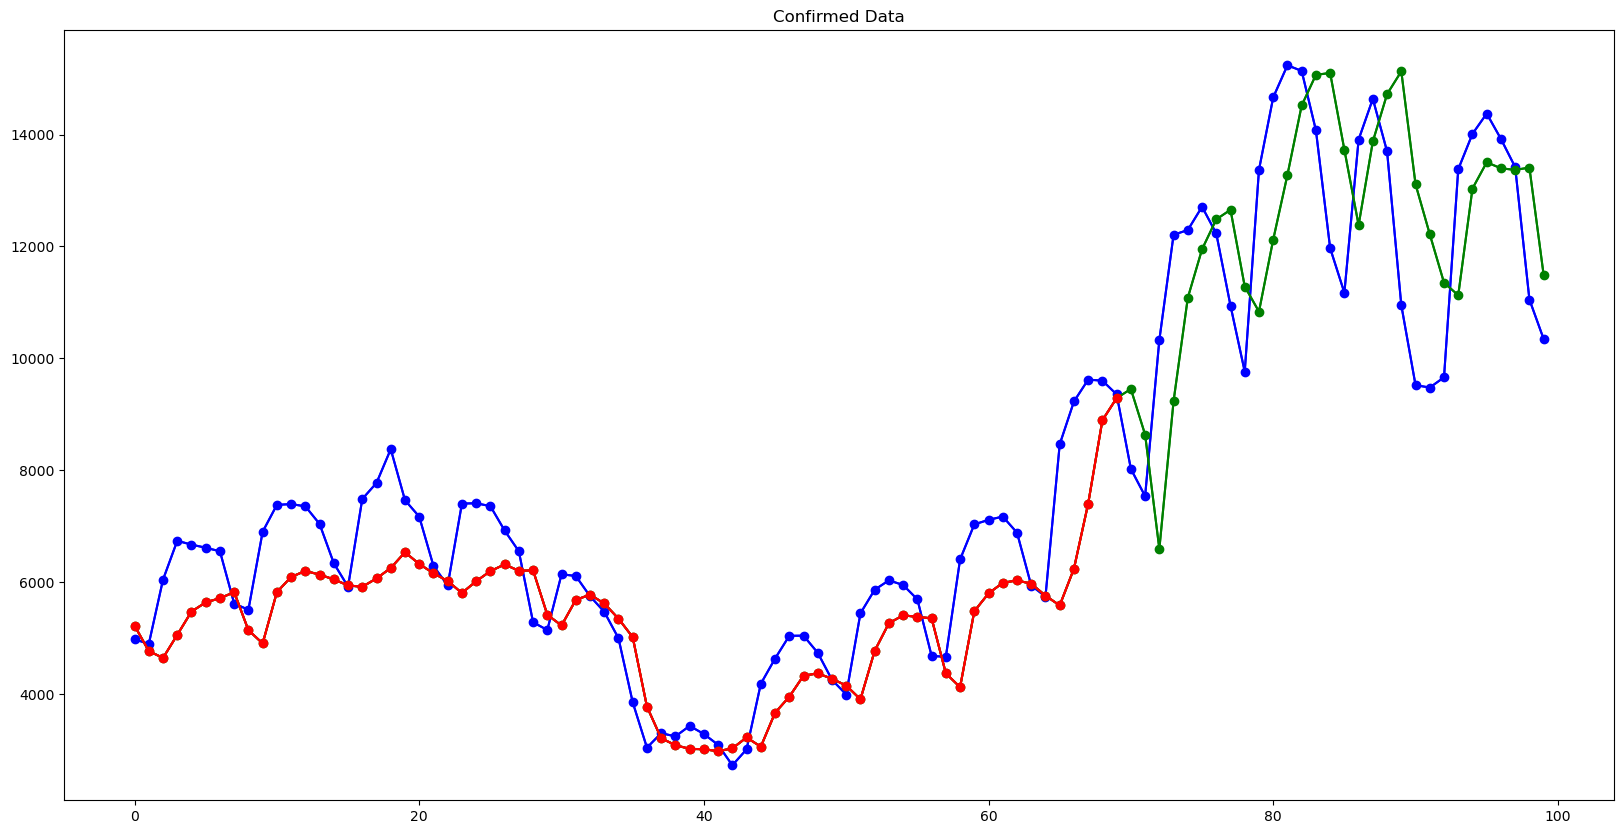

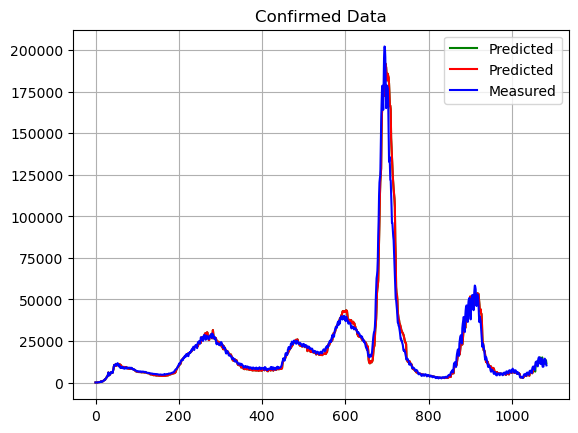

-----------------------------------------------------------------------------------------
| end of epoch 120 | time:  1.54s | mse loss 0.00558 | rmsle loss 0.11021 
-----------------------------------------------------------------------------------------
| epoch 121 |     4/   20 batches | lr 0.000010 | 12.55 ms | loss 0.00356 | ppl     1.00
| epoch 121 |     8/   20 batches | lr 0.000010 | 10.00 ms | loss 0.04683 | ppl     1.05
| epoch 121 |    12/   20 batches | lr 0.000010 | 10.29 ms | loss 0.00348 | ppl     1.00
| epoch 121 |    16/   20 batches | lr 0.000010 |  9.73 ms | loss 0.03808 | ppl     1.04
| epoch 121 |    20/   20 batches | lr 0.000010 |  7.56 ms | loss 0.01238 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 122 |     4/   20 batches | lr 0.000010 | 13.68 ms | loss 0.00358 | ppl     1.00
| epoch 122 |     8/   20 batches | lr 0.000010 |  9.16 ms | loss 0.04732 | ppl     1.05
| epoch 122 |    12/   20 batches | lr 0.000010 |  9.77 ms | loss 0.00332 | ppl     1.00
| epoch 122 |    16/   20 batches | lr 0.000010 |  9.79 ms | loss 0.03946 | ppl     1.04
| epoch 122 |    20/   20 batches | lr 0.000010 |  8.71 ms | loss 0.01171 | ppl     1.01
| epoch 123 |     4/   20 batches | lr 0.000009 | 13.79 ms | loss 0.00351 | ppl     1.00
| epoch 123 |     8/   20 batches | lr 0.000009 | 11.20 ms | loss 0.04757 | ppl     1.05
| epoch 123 |    12/   20 batches | lr 0.000009 | 10.04 ms | loss 0.00339 | ppl     1.00
| epoch 123 |    16/   20 batches | lr 0.000009 |  9.99 ms | loss 0.03836 | ppl     1.04
| epoch 123 |    20/   20 batches | lr 0.000009 |  9.46 ms | loss 0.01231 | ppl     1.01
| epoch 124 |     4/   20 batches | lr 0.000009 | 13.05 ms | loss 0.00354 | ppl     1.00
| epoch 124 |     8/ 

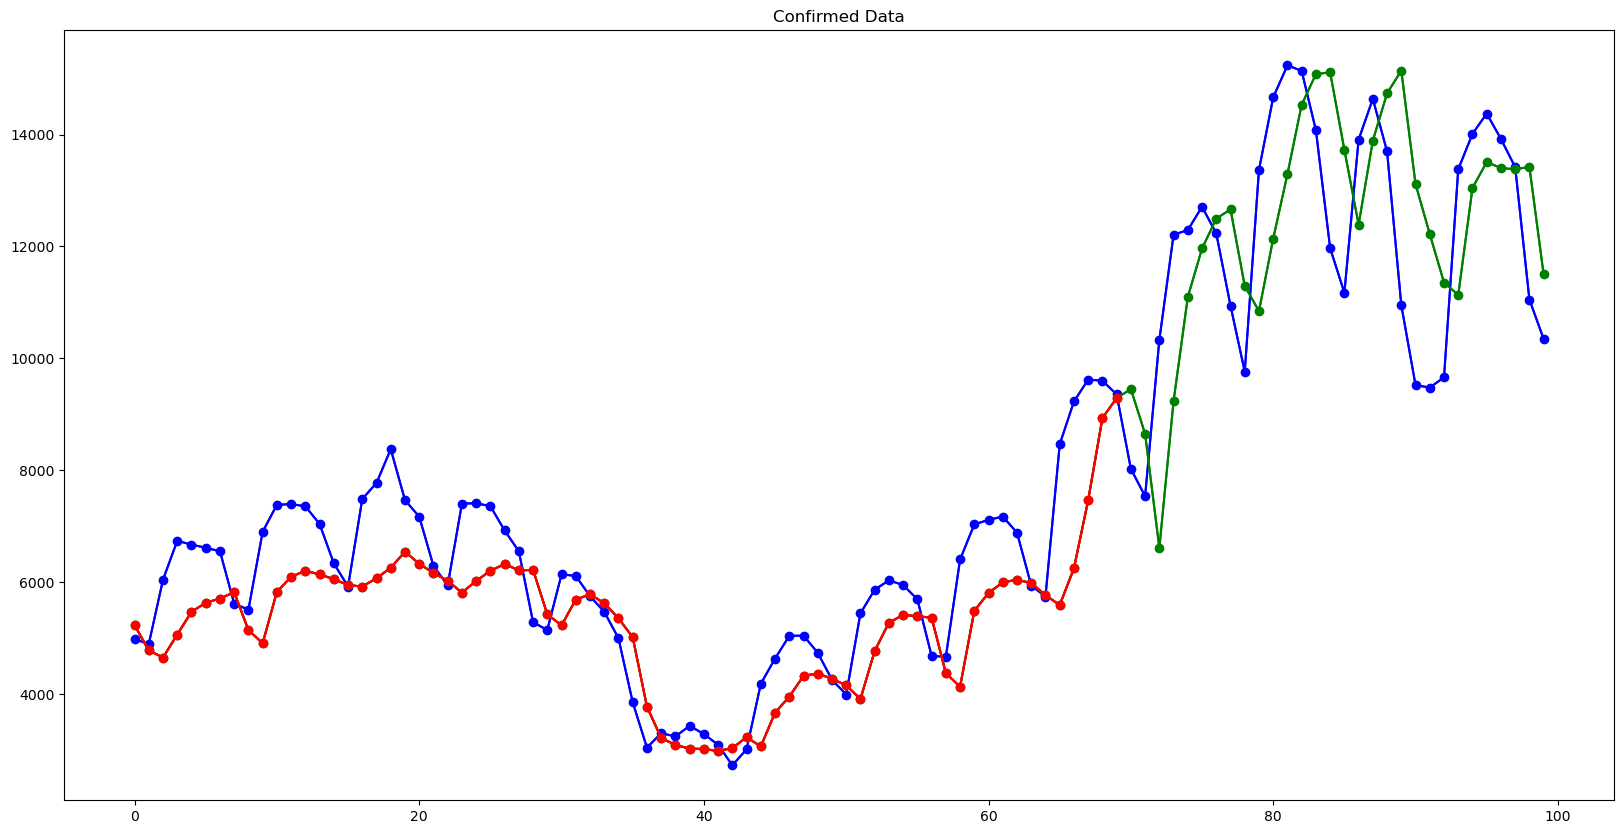

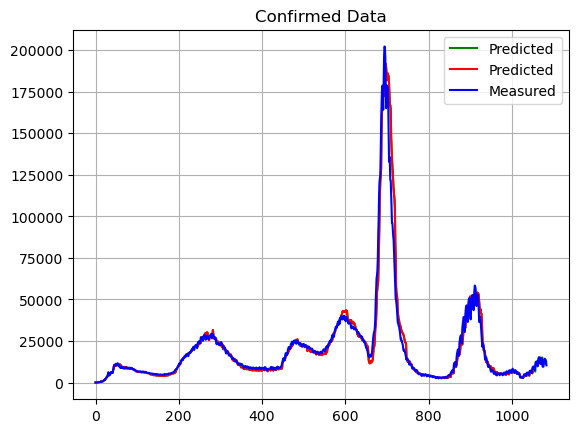

-----------------------------------------------------------------------------------------
| end of epoch 130 | time:  1.81s | mse loss 0.00558 | rmsle loss 0.11014 
-----------------------------------------------------------------------------------------
| epoch 131 |     4/   20 batches | lr 0.000006 | 13.47 ms | loss 0.00351 | ppl     1.00
| epoch 131 |     8/   20 batches | lr 0.000006 | 10.03 ms | loss 0.04777 | ppl     1.05
| epoch 131 |    12/   20 batches | lr 0.000006 |  9.97 ms | loss 0.00337 | ppl     1.00
| epoch 131 |    16/   20 batches | lr 0.000006 | 10.02 ms | loss 0.03702 | ppl     1.04
| epoch 131 |    20/   20 batches | lr 0.000006 |  7.52 ms | loss 0.01219 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 132 |     4/   20 batches | lr 0.000006 | 12.47 ms | loss 0.00354 | ppl     1.00
| epoch 132 |     8/   20 batches | lr 0.000006 | 11.30 ms | loss 0.04860 | ppl     1.05
| epoch 132 |    12/   20 batches | lr 0.000006 | 10.02 ms | loss 0.00330 | ppl     1.00
| epoch 132 |    16/   20 batches | lr 0.000006 | 11.15 ms | loss 0.03717 | ppl     1.04
| epoch 132 |    20/   20 batches | lr 0.000006 |  8.78 ms | loss 0.01224 | ppl     1.01
| epoch 133 |     4/   20 batches | lr 0.000005 | 12.56 ms | loss 0.00345 | ppl     1.00
| epoch 133 |     8/   20 batches | lr 0.000005 | 11.21 ms | loss 0.04657 | ppl     1.05
| epoch 133 |    12/   20 batches | lr 0.000005 | 10.18 ms | loss 0.00333 | ppl     1.00
| epoch 133 |    16/   20 batches | lr 0.000005 |  9.96 ms | loss 0.03820 | ppl     1.04
| epoch 133 |    20/   20 batches | lr 0.000005 |  8.65 ms | loss 0.01220 | ppl     1.01
| epoch 134 |     4/   20 batches | lr 0.000005 | 10.60 ms | loss 0.00355 | ppl     1.00
| epoch 134 |     8/ 

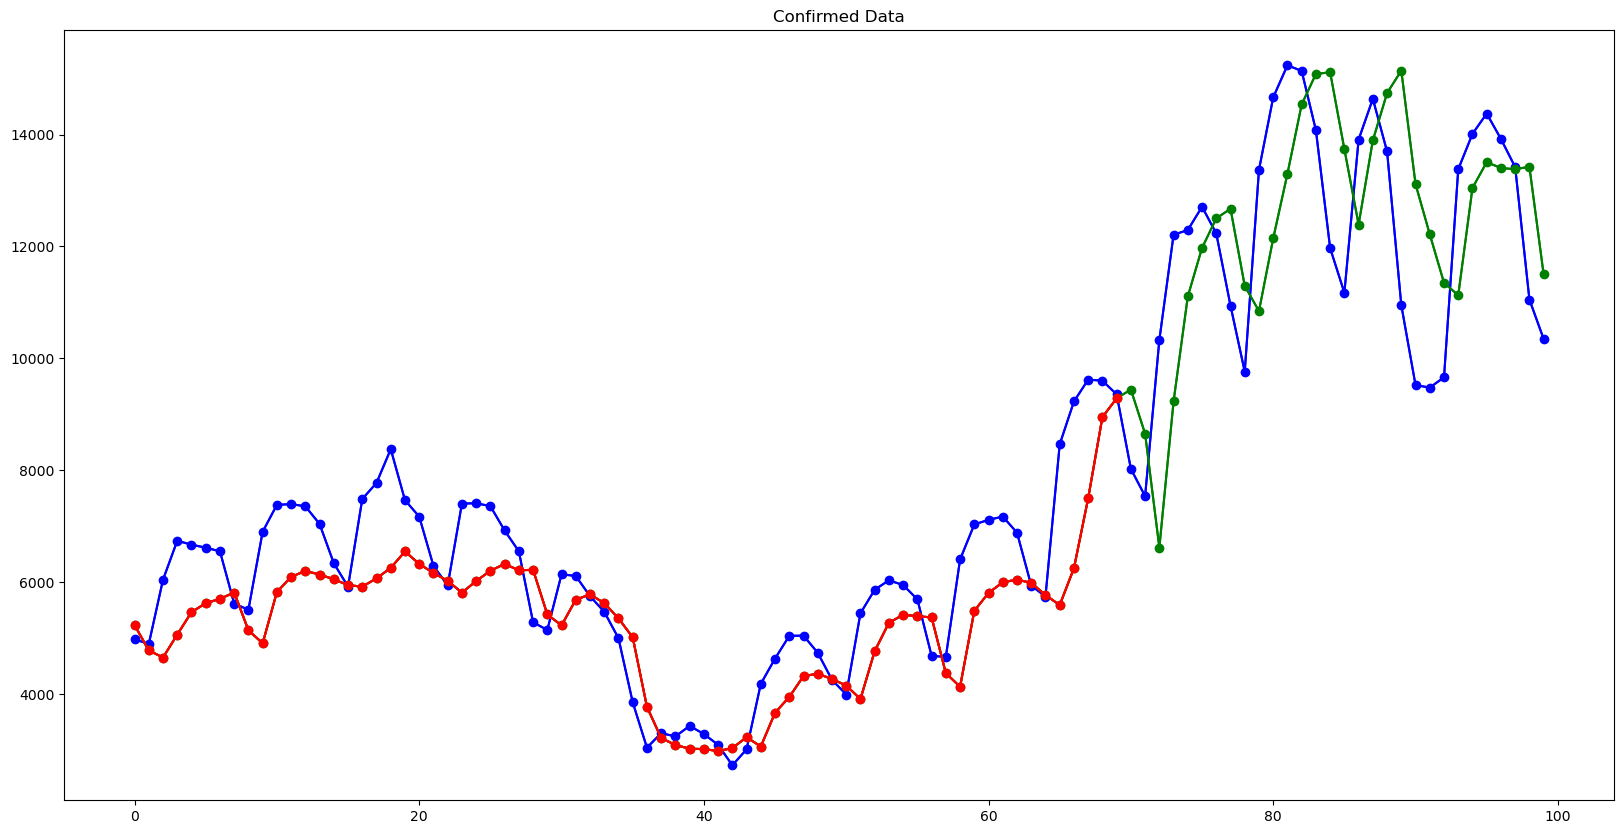

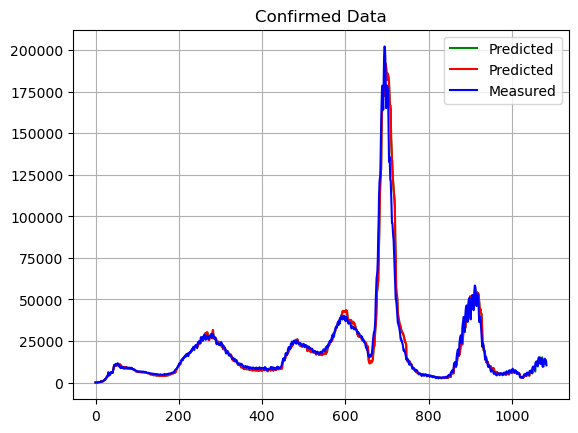

-----------------------------------------------------------------------------------------
| end of epoch 140 | time:  1.67s | mse loss 0.00557 | rmsle loss 0.11011 
-----------------------------------------------------------------------------------------
| epoch 141 |     4/   20 batches | lr 0.000004 | 12.52 ms | loss 0.00347 | ppl     1.00
| epoch 141 |     8/   20 batches | lr 0.000004 |  9.97 ms | loss 0.04549 | ppl     1.05
| epoch 141 |    12/   20 batches | lr 0.000004 | 10.45 ms | loss 0.00335 | ppl     1.00
| epoch 141 |    16/   20 batches | lr 0.000004 |  9.47 ms | loss 0.03893 | ppl     1.04
| epoch 141 |    20/   20 batches | lr 0.000004 | 10.10 ms | loss 0.01187 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 142 |     4/   20 batches | lr 0.000003 | 12.51 ms | loss 0.00357 | ppl     1.00
| epoch 142 |     8/   20 batches | lr 0.000003 |  9.90 ms | loss 0.04561 | ppl     1.05
| epoch 142 |    12/   20 batches | lr 0.000003 | 10.01 ms | loss 0.00333 | ppl     1.00
| epoch 142 |    16/   20 batches | lr 0.000003 | 10.29 ms | loss 0.03894 | ppl     1.04
| epoch 142 |    20/   20 batches | lr 0.000003 |  9.67 ms | loss 0.01242 | ppl     1.01
| epoch 143 |     4/   20 batches | lr 0.000003 | 12.61 ms | loss 0.00350 | ppl     1.00
| epoch 143 |     8/   20 batches | lr 0.000003 |  9.98 ms | loss 0.04595 | ppl     1.05
| epoch 143 |    12/   20 batches | lr 0.000003 |  9.93 ms | loss 0.00338 | ppl     1.00
| epoch 143 |    16/   20 batches | lr 0.000003 | 10.06 ms | loss 0.03798 | ppl     1.04
| epoch 143 |    20/   20 batches | lr 0.000003 |  9.92 ms | loss 0.01192 | ppl     1.01
| epoch 144 |     4/   20 batches | lr 0.000003 | 12.51 ms | loss 0.00345 | ppl     1.00
| epoch 144 |     8/ 

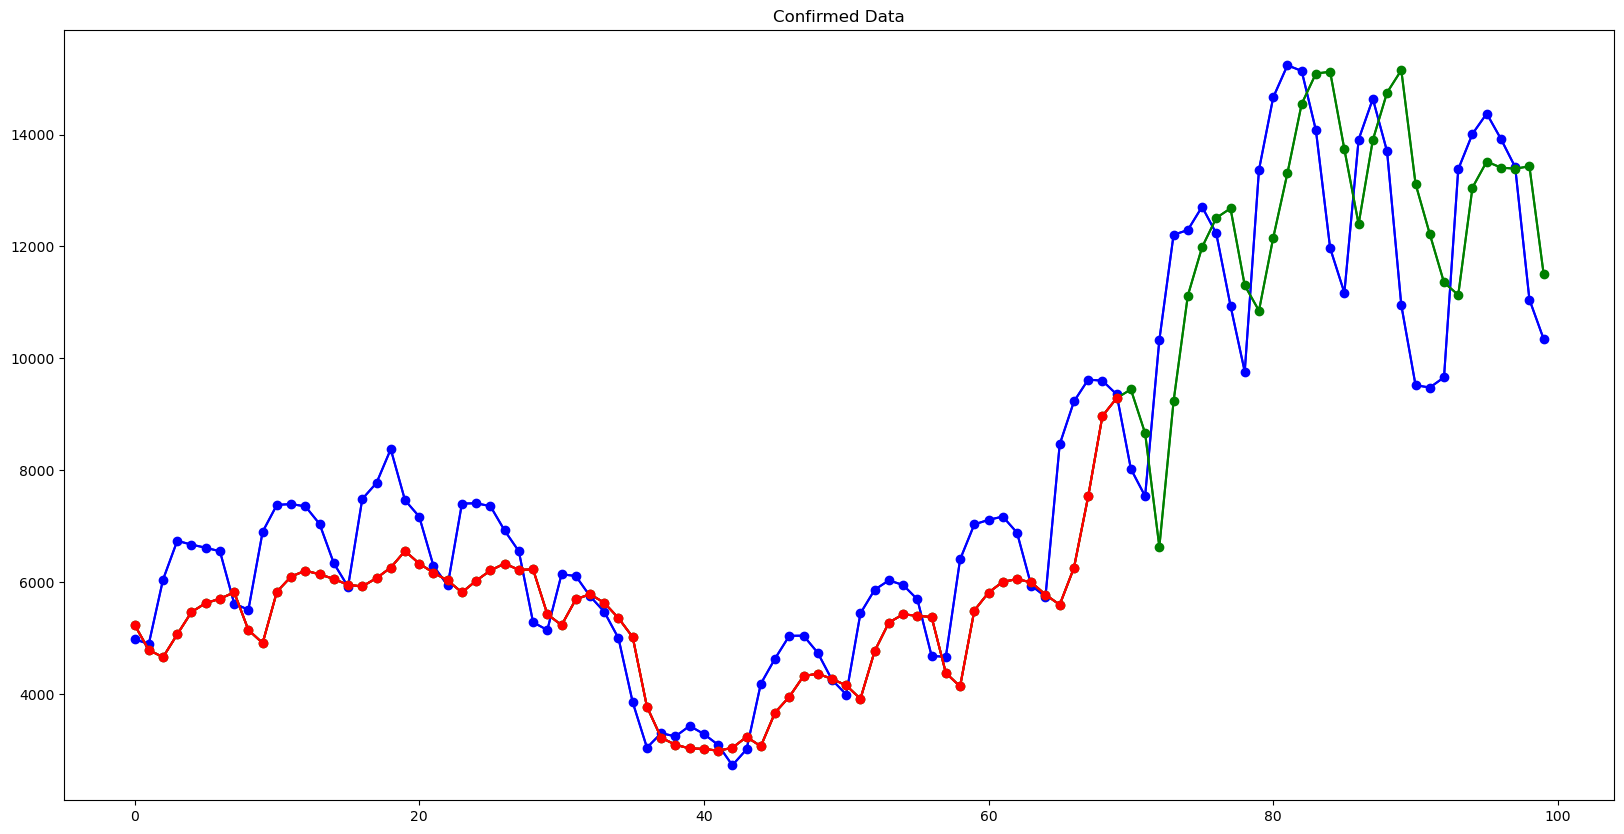

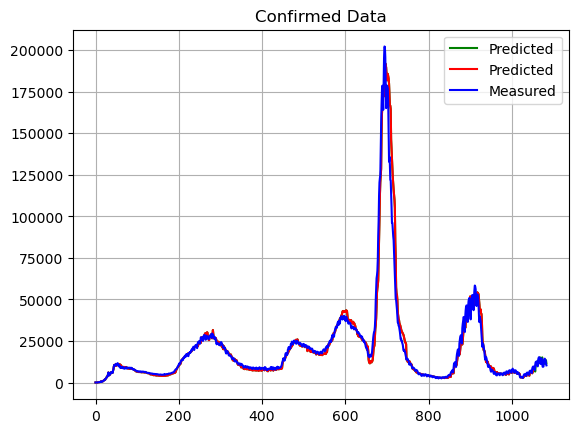

-----------------------------------------------------------------------------------------
| end of epoch 150 | time:  1.75s | mse loss 0.00557 | rmsle loss 0.11007 
-----------------------------------------------------------------------------------------
| epoch 151 |     4/   20 batches | lr 0.000002 | 12.44 ms | loss 0.00355 | ppl     1.00
| epoch 151 |     8/   20 batches | lr 0.000002 | 10.07 ms | loss 0.04578 | ppl     1.05
| epoch 151 |    12/   20 batches | lr 0.000002 | 10.03 ms | loss 0.00345 | ppl     1.00
| epoch 151 |    16/   20 batches | lr 0.000002 | 10.84 ms | loss 0.03804 | ppl     1.04
| epoch 151 |    20/   20 batches | lr 0.000002 |  7.34 ms | loss 0.01194 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 152 |     4/   20 batches | lr 0.000002 | 14.32 ms | loss 0.00353 | ppl     1.00
| epoch 152 |     8/   20 batches | lr 0.000002 |  9.98 ms | loss 0.04588 | ppl     1.05
| epoch 152 |    12/   20 batches | lr 0.000002 | 10.02 ms | loss 0.00341 | ppl     1.00
| epoch 152 |    16/   20 batches | lr 0.000002 | 10.33 ms | loss 0.03722 | ppl     1.04
| epoch 152 |    20/   20 batches | lr 0.000002 |  7.17 ms | loss 0.01244 | ppl     1.01
| epoch 153 |     4/   20 batches | lr 0.000002 | 15.02 ms | loss 0.00345 | ppl     1.00
| epoch 153 |     8/   20 batches | lr 0.000002 | 10.03 ms | loss 0.04757 | ppl     1.05
| epoch 153 |    12/   20 batches | lr 0.000002 |  9.93 ms | loss 0.00337 | ppl     1.00
| epoch 153 |    16/   20 batches | lr 0.000002 |  9.94 ms | loss 0.03448 | ppl     1.04
| epoch 153 |    20/   20 batches | lr 0.000002 | 10.02 ms | loss 0.01204 | ppl     1.01
| epoch 154 |     4/   20 batches | lr 0.000002 | 13.25 ms | loss 0.00348 | ppl     1.00
| epoch 154 |     8/ 

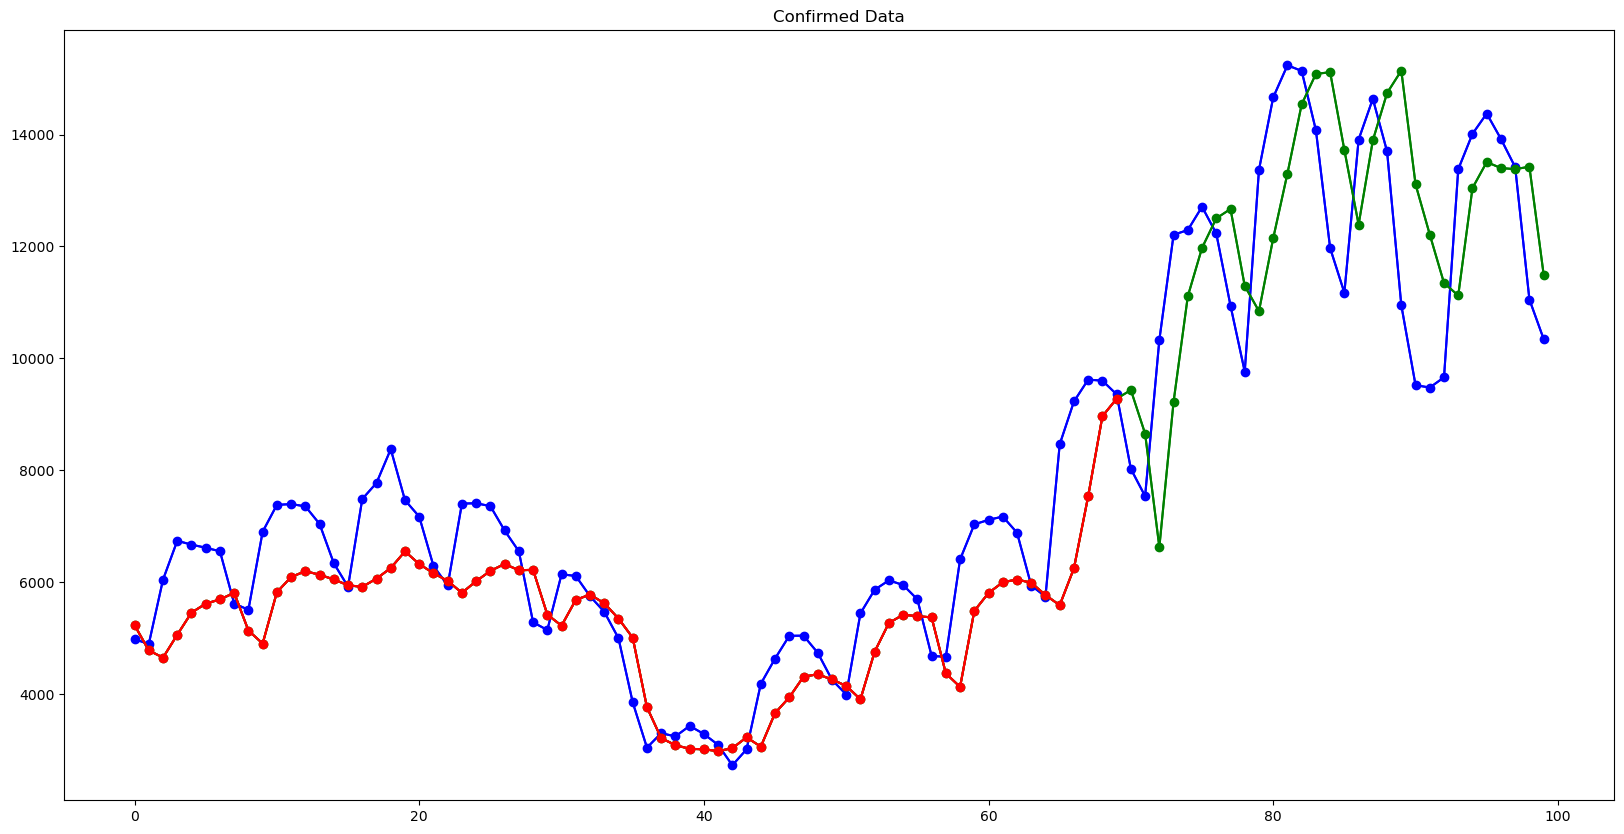

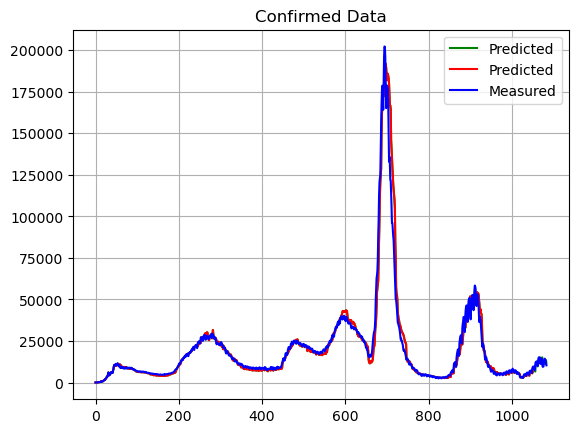

-----------------------------------------------------------------------------------------
| end of epoch 160 | time:  1.56s | mse loss 0.00557 | rmsle loss 0.11002 
-----------------------------------------------------------------------------------------
| epoch 161 |     4/   20 batches | lr 0.000001 | 12.42 ms | loss 0.00347 | ppl     1.00
| epoch 161 |     8/   20 batches | lr 0.000001 | 12.49 ms | loss 0.04769 | ppl     1.05
| epoch 161 |    12/   20 batches | lr 0.000001 |  9.97 ms | loss 0.00332 | ppl     1.00
| epoch 161 |    16/   20 batches | lr 0.000001 | 10.12 ms | loss 0.04017 | ppl     1.04
| epoch 161 |    20/   20 batches | lr 0.000001 |  8.46 ms | loss 0.01197 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 162 |     4/   20 batches | lr 0.000001 | 14.00 ms | loss 0.00356 | ppl     1.00
| epoch 162 |     8/   20 batches | lr 0.000001 | 10.74 ms | loss 0.04748 | ppl     1.05
| epoch 162 |    12/   20 batches | lr 0.000001 |  9.28 ms | loss 0.00339 | ppl     1.00
| epoch 162 |    16/   20 batches | lr 0.000001 |  9.97 ms | loss 0.03801 | ppl     1.04
| epoch 162 |    20/   20 batches | lr 0.000001 |  8.91 ms | loss 0.01240 | ppl     1.01
| epoch 163 |     4/   20 batches | lr 0.000001 | 11.10 ms | loss 0.00349 | ppl     1.00
| epoch 163 |     8/   20 batches | lr 0.000001 |  9.98 ms | loss 0.04585 | ppl     1.05
| epoch 163 |    12/   20 batches | lr 0.000001 | 12.87 ms | loss 0.00342 | ppl     1.00
| epoch 163 |    16/   20 batches | lr 0.000001 |  9.56 ms | loss 0.03752 | ppl     1.04
| epoch 163 |    20/   20 batches | lr 0.000001 |  7.61 ms | loss 0.01168 | ppl     1.01
| epoch 164 |     4/   20 batches | lr 0.000001 | 14.90 ms | loss 0.00347 | ppl     1.00
| epoch 164 |     8/ 

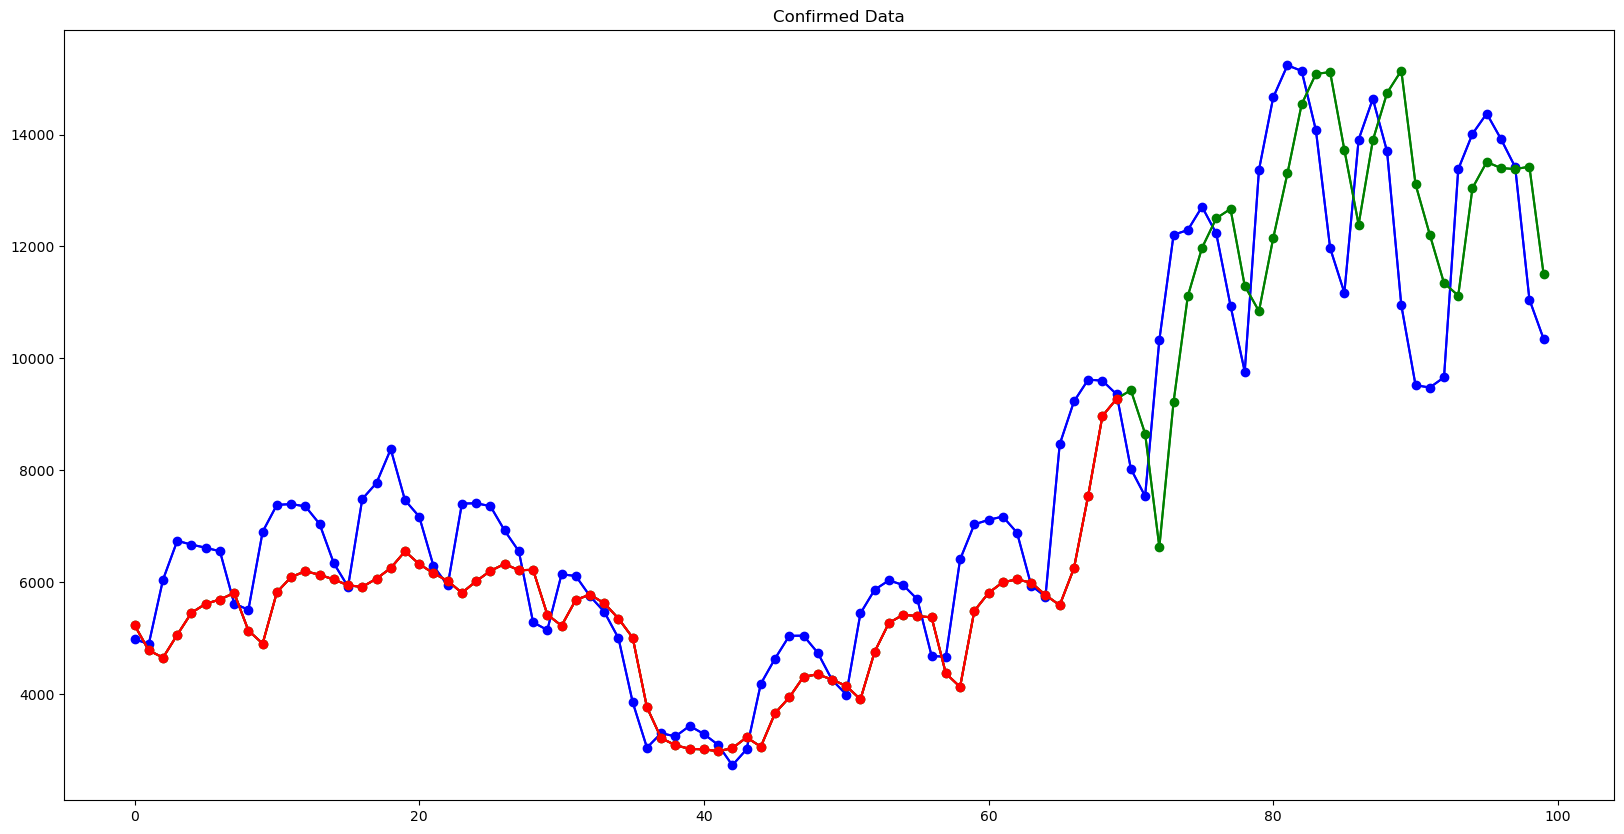

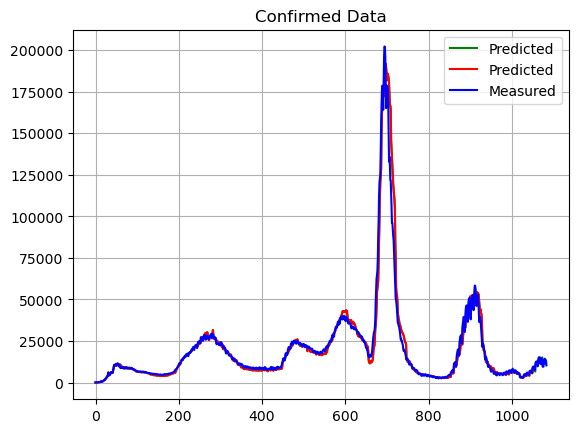

-----------------------------------------------------------------------------------------
| end of epoch 170 | time:  1.54s | mse loss 0.00557 | rmsle loss 0.11002 
-----------------------------------------------------------------------------------------
| epoch 171 |     4/   20 batches | lr 0.000001 | 12.59 ms | loss 0.00344 | ppl     1.00
| epoch 171 |     8/   20 batches | lr 0.000001 |  9.97 ms | loss 0.04668 | ppl     1.05
| epoch 171 |    12/   20 batches | lr 0.000001 |  9.91 ms | loss 0.00332 | ppl     1.00
| epoch 171 |    16/   20 batches | lr 0.000001 | 10.03 ms | loss 0.03637 | ppl     1.04
| epoch 171 |    20/   20 batches | lr 0.000001 |  7.86 ms | loss 0.01117 | ppl     1.01


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 172 |     4/   20 batches | lr 0.000001 | 14.93 ms | loss 0.00350 | ppl     1.00
| epoch 172 |     8/   20 batches | lr 0.000001 |  9.79 ms | loss 0.04390 | ppl     1.04
| epoch 172 |    12/   20 batches | lr 0.000001 |  9.94 ms | loss 0.00336 | ppl     1.00
| epoch 172 |    16/   20 batches | lr 0.000001 |  9.96 ms | loss 0.03771 | ppl     1.04
| epoch 172 |    20/   20 batches | lr 0.000001 | 10.12 ms | loss 0.01219 | ppl     1.01
| epoch 173 |     4/   20 batches | lr 0.000001 | 12.42 ms | loss 0.00349 | ppl     1.00
| epoch 173 |     8/   20 batches | lr 0.000001 | 11.83 ms | loss 0.04790 | ppl     1.05
| epoch 173 |    12/   20 batches | lr 0.000001 |  8.28 ms | loss 0.00330 | ppl     1.00
| epoch 173 |    16/   20 batches | lr 0.000001 | 10.58 ms | loss 0.03893 | ppl     1.04
| epoch 173 |    20/   20 batches | lr 0.000001 |  6.87 ms | loss 0.01244 | ppl     1.01
| epoch 174 |     4/   20 batches | lr 0.000001 | 15.01 ms | loss 0.00354 | ppl     1.00
| epoch 174 |     8/ 

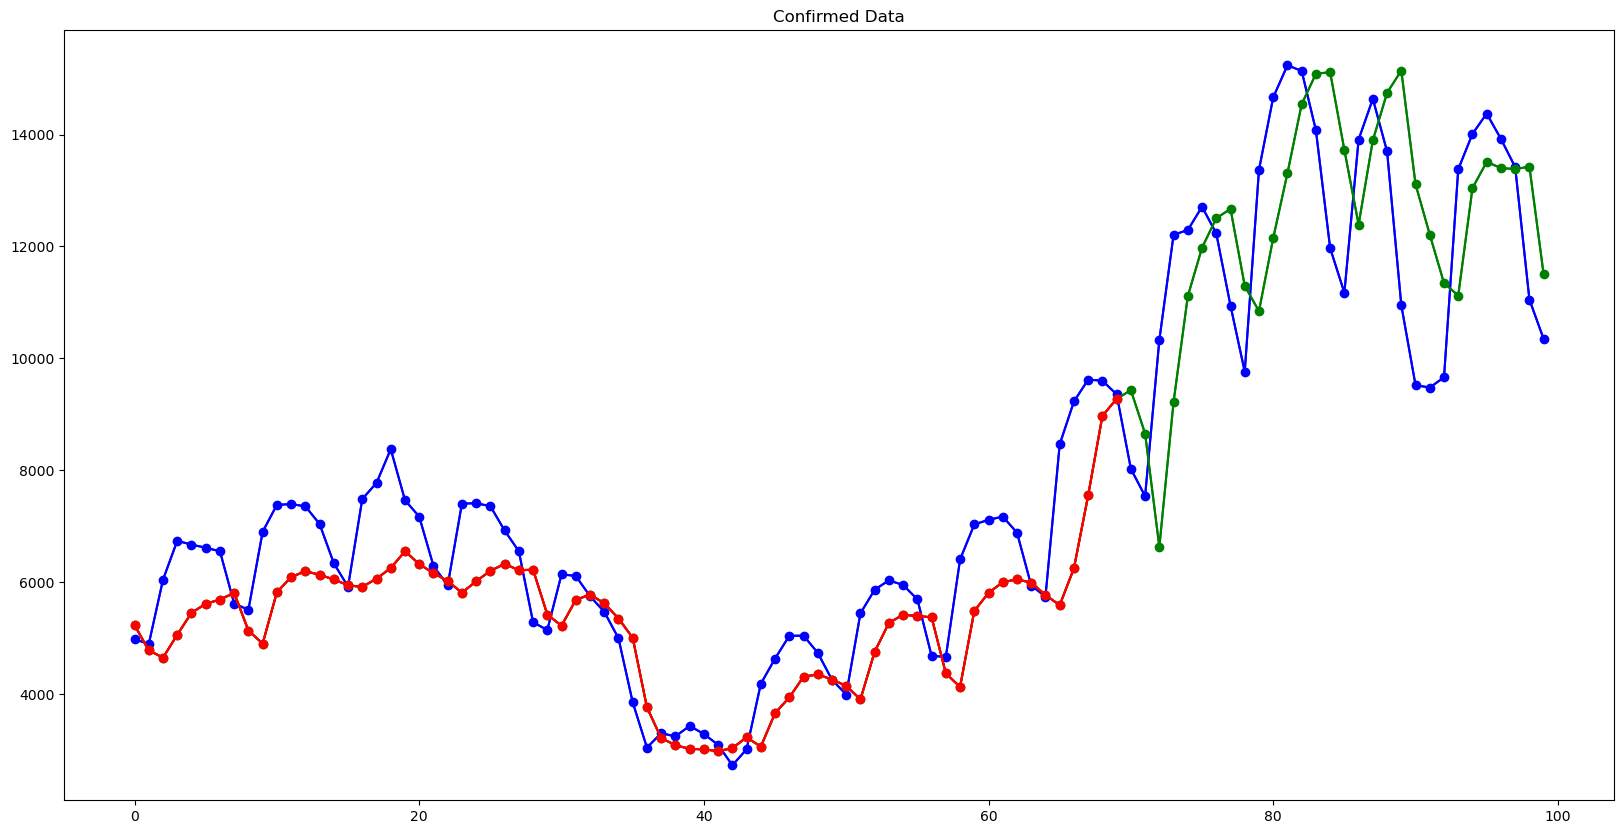

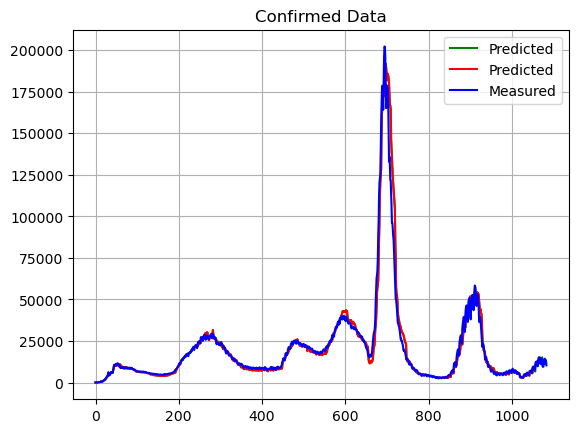

-----------------------------------------------------------------------------------------
| end of epoch 180 | time:  1.69s | mse loss 0.00556 | rmsle loss 0.11000 
-----------------------------------------------------------------------------------------
| epoch 181 |     4/   20 batches | lr 0.000000 | 12.29 ms | loss 0.00351 | ppl     1.00
| epoch 181 |     8/   20 batches | lr 0.000000 |  9.97 ms | loss 0.04711 | ppl     1.05
| epoch 181 |    12/   20 batches | lr 0.000000 | 10.04 ms | loss 0.00332 | ppl     1.00
| epoch 181 |    16/   20 batches | lr 0.000000 | 10.03 ms | loss 0.03918 | ppl     1.04


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 181 |    20/   20 batches | lr 0.000000 |  8.75 ms | loss 0.01201 | ppl     1.01
| epoch 182 |     4/   20 batches | lr 0.000000 | 13.51 ms | loss 0.00343 | ppl     1.00
| epoch 182 |     8/   20 batches | lr 0.000000 | 10.17 ms | loss 0.04631 | ppl     1.05
| epoch 182 |    12/   20 batches | lr 0.000000 | 11.23 ms | loss 0.00335 | ppl     1.00
| epoch 182 |    16/   20 batches | lr 0.000000 | 10.02 ms | loss 0.03877 | ppl     1.04
| epoch 182 |    20/   20 batches | lr 0.000000 |  8.79 ms | loss 0.01227 | ppl     1.01
| epoch 183 |     4/   20 batches | lr 0.000000 | 12.45 ms | loss 0.00347 | ppl     1.00
| epoch 183 |     8/   20 batches | lr 0.000000 | 10.02 ms | loss 0.04777 | ppl     1.05
| epoch 183 |    12/   20 batches | lr 0.000000 | 10.04 ms | loss 0.00332 | ppl     1.00
| epoch 183 |    16/   20 batches | lr 0.000000 | 11.63 ms | loss 0.03934 | ppl     1.04
| epoch 183 |    20/   20 batches | lr 0.000000 |  8.28 ms | loss 0.01226 | ppl     1.01
| epoch 184 |     4/ 

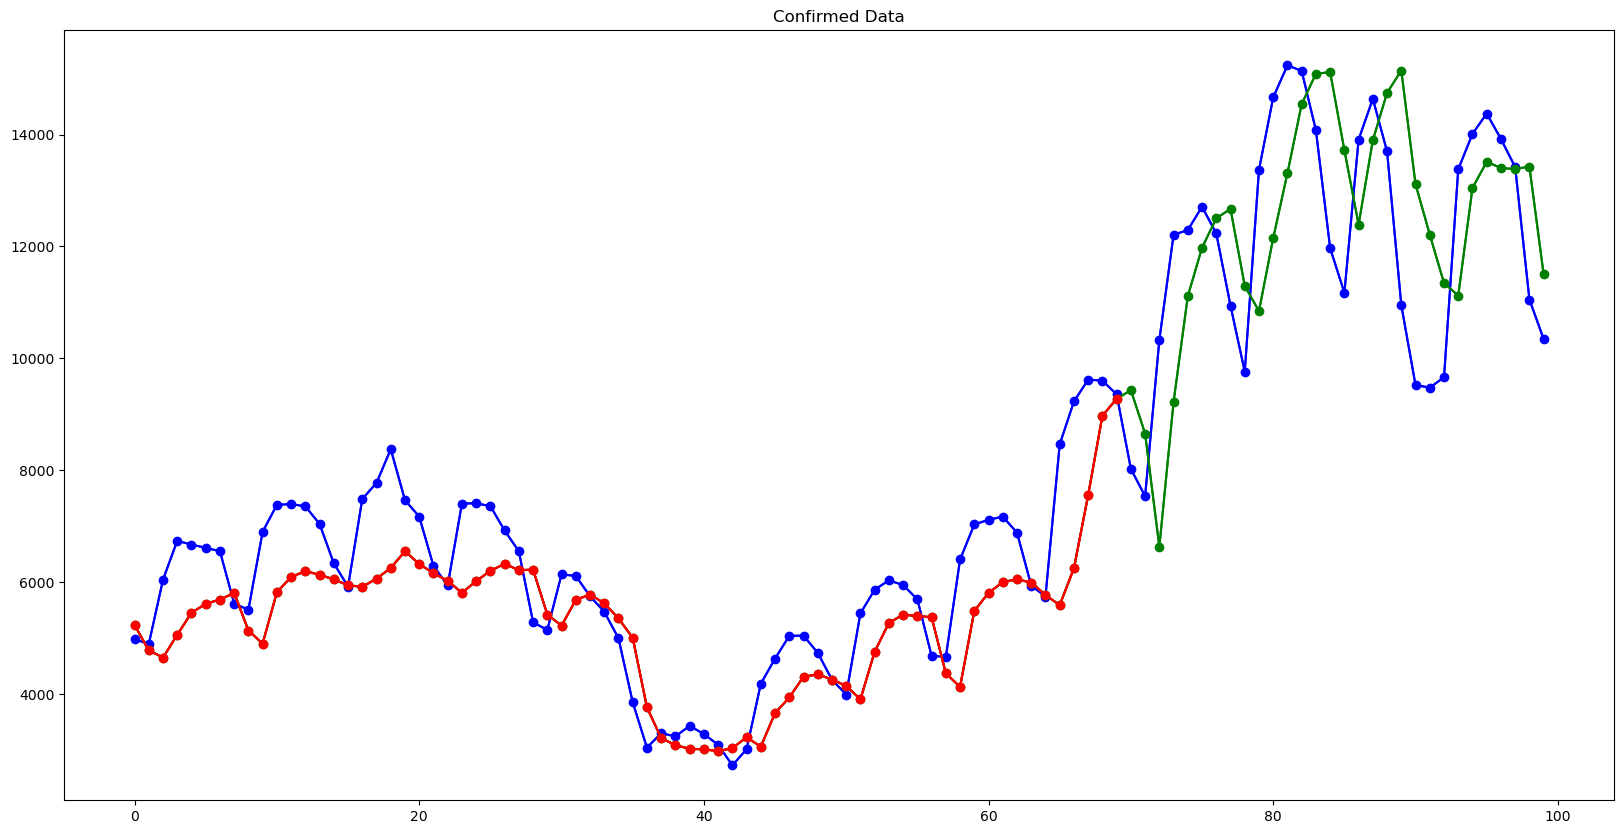

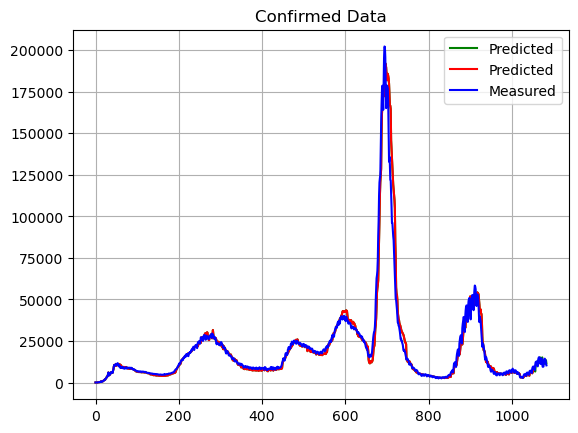

-----------------------------------------------------------------------------------------
| end of epoch 190 | time:  1.84s | mse loss 0.00556 | rmsle loss 0.10999 
-----------------------------------------------------------------------------------------
| epoch 191 |     4/   20 batches | lr 0.000000 | 13.37 ms | loss 0.00356 | ppl     1.00
| epoch 191 |     8/   20 batches | lr 0.000000 |  9.43 ms | loss 0.04828 | ppl     1.05
| epoch 191 |    12/   20 batches | lr 0.000000 | 10.99 ms | loss 0.00340 | ppl     1.00
| epoch 191 |    16/   20 batches | lr 0.000000 |  8.71 ms | loss 0.03887 | ppl     1.04


C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\optim\lr_scheduler.py:536: UserWarning:

To get the last learning rate computed by the scheduler, please use `get_last_lr()`.



| epoch 191 |    20/   20 batches | lr 0.000000 | 10.09 ms | loss 0.01163 | ppl     1.01
| epoch 192 |     4/   20 batches | lr 0.000000 | 12.45 ms | loss 0.00349 | ppl     1.00
| epoch 192 |     8/   20 batches | lr 0.000000 |  9.96 ms | loss 0.04596 | ppl     1.05
| epoch 192 |    12/   20 batches | lr 0.000000 | 10.00 ms | loss 0.00331 | ppl     1.00
| epoch 192 |    16/   20 batches | lr 0.000000 | 10.10 ms | loss 0.03728 | ppl     1.04
| epoch 192 |    20/   20 batches | lr 0.000000 |  7.51 ms | loss 0.01176 | ppl     1.01
| epoch 193 |     4/   20 batches | lr 0.000000 | 12.45 ms | loss 0.00354 | ppl     1.00
| epoch 193 |     8/   20 batches | lr 0.000000 | 10.27 ms | loss 0.04620 | ppl     1.05
| epoch 193 |    12/   20 batches | lr 0.000000 | 12.27 ms | loss 0.00341 | ppl     1.00
| epoch 193 |    16/   20 batches | lr 0.000000 |  9.98 ms | loss 0.03958 | ppl     1.04
| epoch 193 |    20/   20 batches | lr 0.000000 |  7.46 ms | loss 0.01188 | ppl     1.01
| epoch 194 |     4/ 

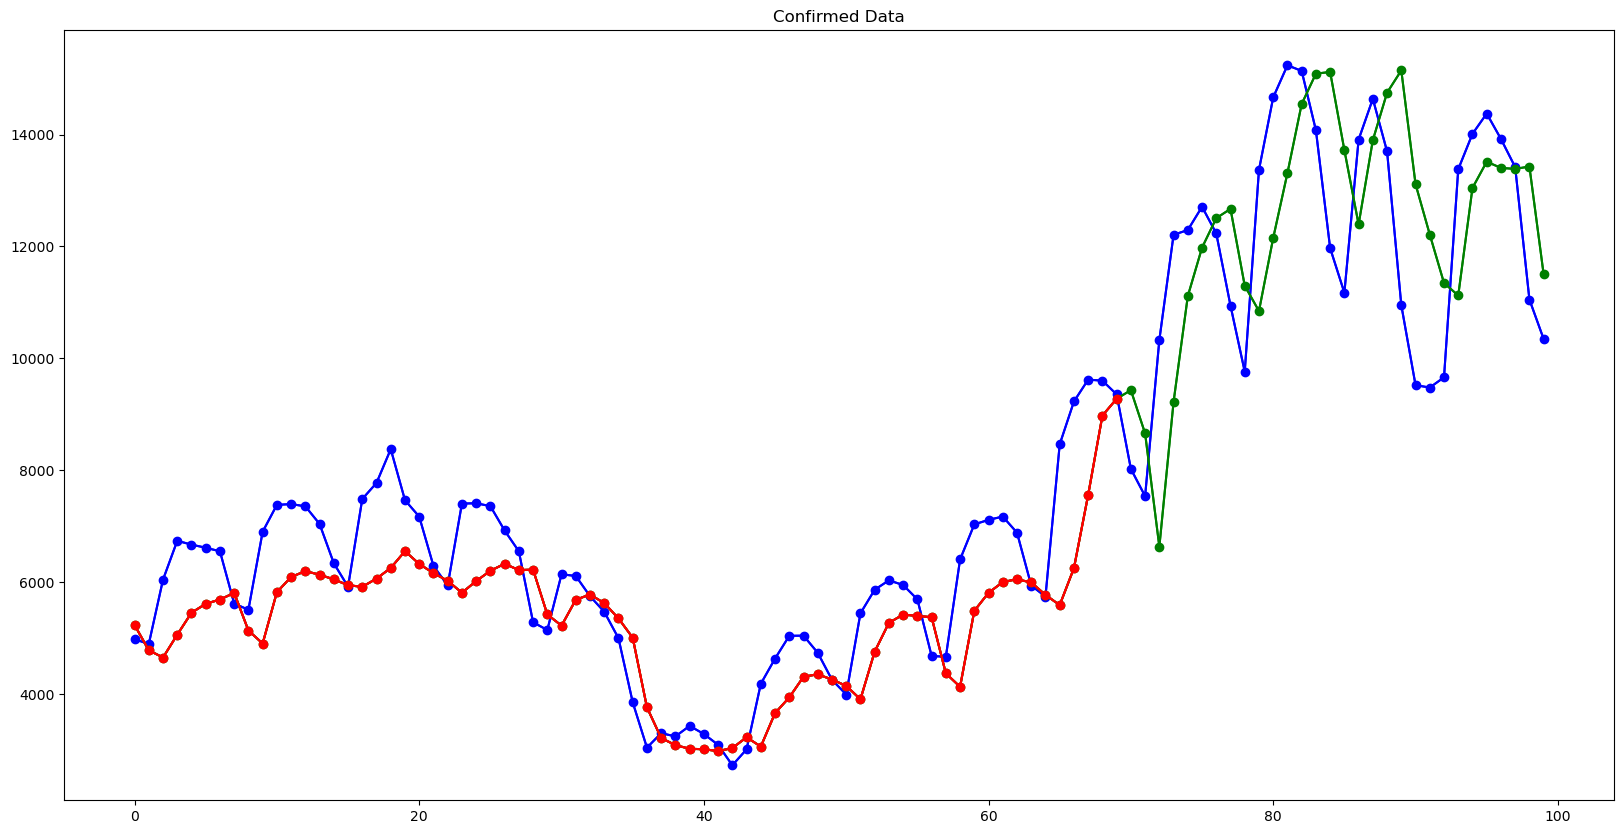

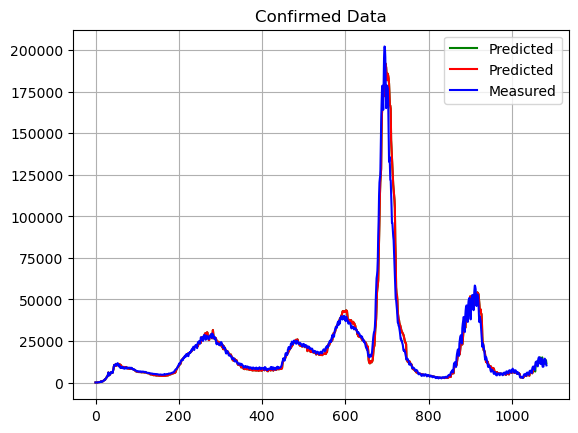

-----------------------------------------------------------------------------------------
| end of epoch 200 | time:  1.66s | mse loss 0.00556 | rmsle loss 0.10999 
-----------------------------------------------------------------------------------------


In [32]:
dealData = DealData("data/Russia.csv",
                   #'ganDataNew/stand_russia_del30_confirmed_noise_1000.npy'
                   )
train_data, val_data = dealData.trainTestData()
# train_data = dealData.train_data()
model = TransAm().to(device)

criterion = nn.MSELoss()
lr = 0.005 
#optimizer = torch.optim.SGD(model.parameters(), lr=lr)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

best_val_loss = float("inf")
epochs = 200 # The number of epochs
best_model = None

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(train_data)

    if(epoch % 10 is 0):
#         mse, rmsle, truth, test_result = dealData.get_plot_data(model)
#         plot_image(truth, test_result)
        mse, rmsle = dealData.plot_and_loss(model, epoch, True)
        print('-' * 89)
        print('| end of epoch {:3d} | time: {:5.2f}s | mse loss {:5.5f} | rmsle loss {:5.5f} '.format(epoch, (time.time() - epoch_start_time),
                                         mse, rmsle))
        print('-' * 89)

    scheduler.step() 
#     saveModel(model, "parameter_global_confirmed_50sq_del30_changeLoss_noise_" + str(i) + "_best") 

In [33]:
saveModel(model, "parameter_russia_confirmed_50sq_del30_noGAN_best_everyday") 

# Load Model

C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)

C:\Users\user\AppData\Local\Temp\ipykernel_18416\848880480.py:319: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_sa

1084 1084
mse:  0.005564940498379204
rmsle:  0.1099932610811104
mae:  0.06379113843043645
mape:  0.21481054
rmse:  0.0745985287950051


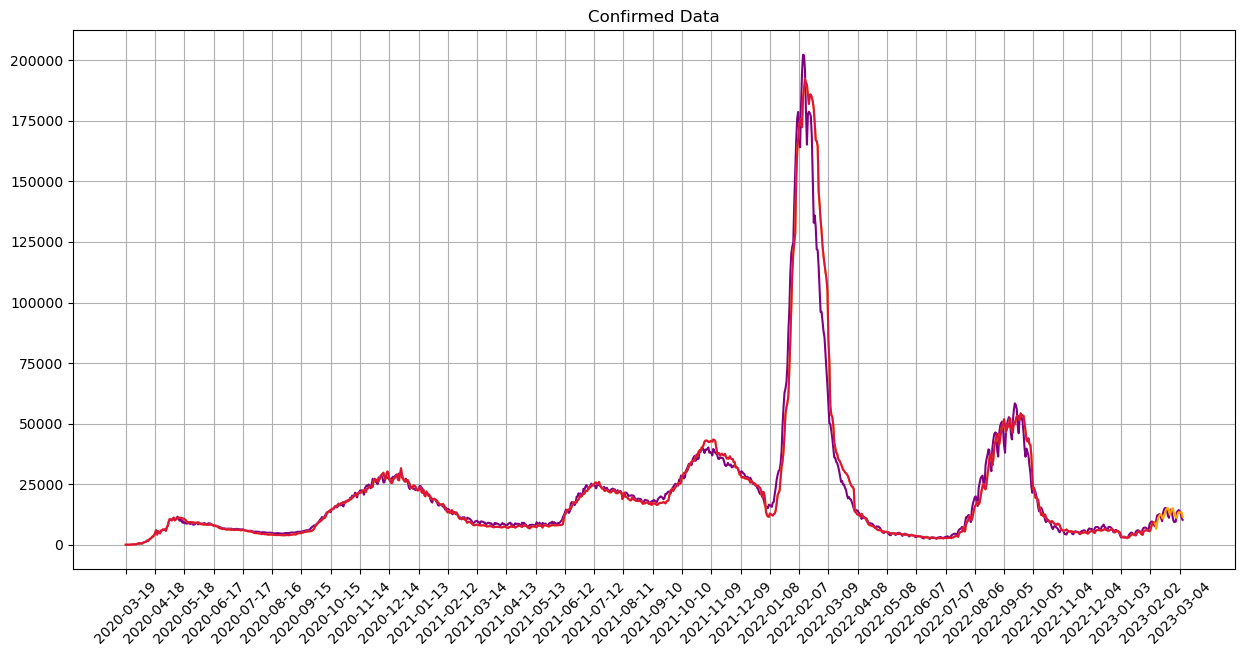

In [34]:
pmodel = TransAm().to(device)
pmodel = loadModel(pmodel, "parameter_russia_confirmed_50sq_del30_noGAN_best_everyday")

dealData = DealData("data/Russia.csv")
df = pd.read_csv("data/Russia.csv")
mse, rmsle, mae, mape, rmse, truth, test_result = dealData.get_plot_data(pmodel)
print("mse: ", mse)
print("rmsle: ", rmsle)
print("mae: ", mae)
print("mape: ", mape)
print("rmse: ", rmse)
plot_image(truth, test_result, start = df.date[0], end = df.date[df.shape[0]-1], 
           title = 'Confirmed Data', isSave = False)

C:\Users\user\anaconda3\envs\sir_gan\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning:

enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)

C:\Users\user\AppData\Local\Temp\ipykernel_18416\848880480.py:319: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_sa

1084 1084
mse:  0.00846692156303667
rmsle:  0.1338864769232719
mae:  0.08073410342137019
mape:  0.30150098
rmse:  0.09201587669004013


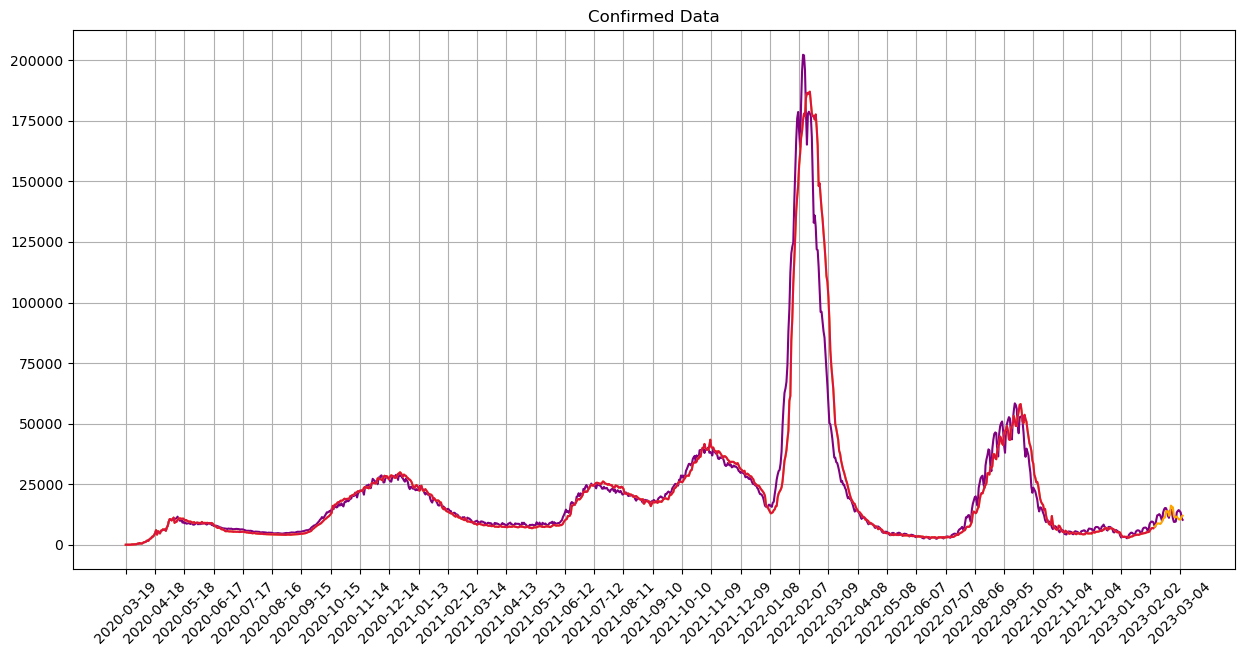

In [31]:
pmodel = TransAm().to(device)
pmodel = loadModel(pmodel, "parameter_russia_confirmed_50sq_del30_noise_best_everyday")

dealData = DealData("data/Russia.csv",
                        "ganDataNew/stand_russia_del30_confirmed_noise_1000.npy")
df = pd.read_csv("data/Russia.csv")
mse, rmsle, mae, mape, rmse, truth, test_result = dealData.get_plot_data(pmodel)
print("mse: ", mse)
print("rmsle: ", rmsle)
print("mae: ", mae)
print("mape: ", mape)
print("rmse: ", rmse)
plot_image(truth, test_result, start = df.date[0], end = df.date[df.shape[0]-1], 
           title = 'Confirmed Data', isSave = False)

460 460
mse:  0.116622284
rmsle:  0.1352534
mae:  0.28296223
mape:  0.19939594
rmse:  0.34150004


/opt/anaconda3/lib/python3.6/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

/opt/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:237: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.



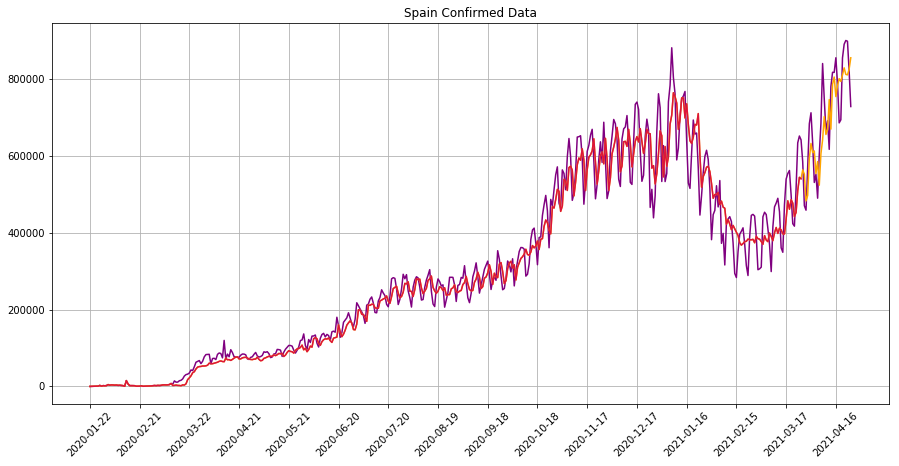

In [36]:
pmodel = TransAm().to(device)
pmodel = loadModel(pmodel, "parameter_global_confirmed_50sq_del30_SJ_best_everyday")
dealData = DealData("/home/soul/NewWorkSpace/Covid_2021_4_18/data/global.csv",
                        "/home/soul/NewWorkSpace/Covid_2021_4_18/ganDataNew/stand_global_del30_confirmed_SJ_noise_1000_everyday.npy")
df = pd.read_csv("/home/soul/NewWorkSpace/Covid_2021_4_18/data/global.csv")
mse, rmsle, mae, mape, rmse, truth, test_result = dealData.get_plot_data(pmodel)
print("mse: ", mse)
print("rmsle: ", rmsle)
print("mae: ", mae)
print("mape: ", mape)
print("rmse: ", rmse)
plot_image(truth, test_result, start = df.date[0], end = df.date[df.shape[0]-1], title = 'Spain Confirmed Data', isSave = True)

460 460
mse:  0.15205194
rmsle:  0.15026234
mae:  0.32773414
mape:  0.21799569
rmse:  0.38993838


/opt/anaconda3/lib/python3.6/site-packages/matplotlib/cbook/__init__.py:1377: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.

/opt/anaconda3/lib/python3.6/site-packages/matplotlib/axes/_base.py:237: FutureWarning:

Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.



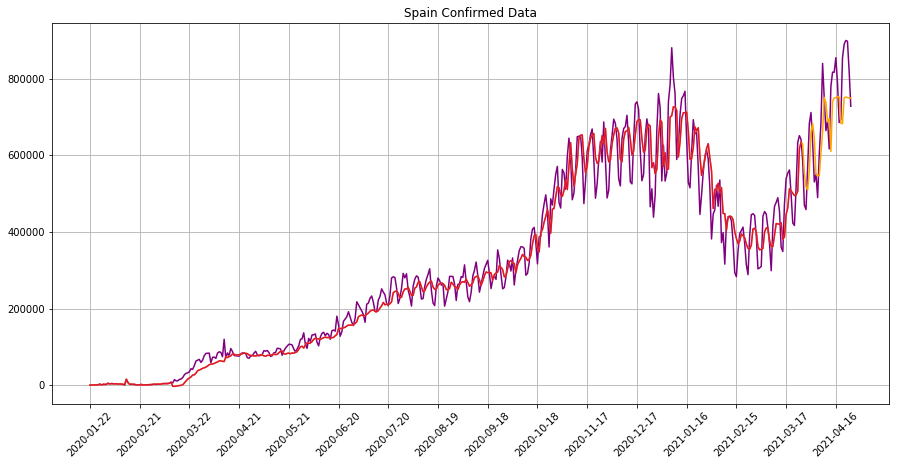

In [37]:
pmodel = TransAm().to(device)
pmodel = loadModel(pmodel, "parameter_global_confirmed_50sq_del30_NoGan_best_everyday")
dealData = DealData("/home/soul/NewWorkSpace/Covid_2021_4_18/data/global.csv")
df = pd.read_csv("/home/soul/NewWorkSpace/Covid_2021_4_18/data/global.csv")
mse, rmsle, mae, mape, rmse, truth, test_result = dealData.get_plot_data(pmodel)
print("mse: ", mse)
print("rmsle: ", rmsle)
print("mae: ", mae)
print("mape: ", mape)
print("rmse: ", rmse)
plot_image(truth, test_result, start = df.date[0], end = df.date[df.shape[0]-1], title = 'Spain Confirmed Data', isSave = True)